# Исследование датасета аренды и продаж турецкой недвижимости
## Обучение моделей для предсказывания стоимости жилья

## Знакомство с данными

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Библиотеки успешно загружены")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Библиотеки успешно загружены
Pandas version: 2.2.3
NumPy version: 2.1.3


In [6]:
df = pd.read_csv('real_estate_data.csv')


print(f"Фактически загружено строк: {df.shape[0]: }")
print(f"Фактически загружено столбцов: {df.shape[1]}")

Фактически загружено строк:  403487
Фактически загружено столбцов: 17


In [3]:
df.head()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


In [4]:
df.tail()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403482,403483,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403483,403484,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403484,403485,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403485,403486,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403486,403487,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


In [5]:
df.sample(n=1)

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
184570,184571,Konut,Daire,2/6/19,NaN,1,21,0,2,2,1+1,60.0,Eskişehir/Odunpazarı/Büyükdere,NaN,Kombi (Doğalgaz),130000.0,TRY


id — уникальный идентификатор объявления

type — тип недвижимости (Konut — жилая)

sub_type — подтип жилья (Daire — квартира, Rezidans — резиденция, Villa — вилла, Müstakil Ev — отдельный дом и др.)

start_date — дата публикации объявления в формате MM/DD/YY

end_date — дата снятия объявления с публикации в формате MM/DD/YY (пусто, если объявление активно)

listing_type — тип сделки (1 — продажа, 2 — аренда, 3 — прочее)

tom — Time On Market, время экспозиции объявления в днях (разница между end_date и start_date)

building_age — возраст здания (числа 0–5 и диапазоны 5-10, 11-15, 16-20, 21-25, 26-30, 31-35, 36-40, 40 ve üzeri — «40 и выше»)

total_floor_count — общее число этажей в доме (числа и диапазон 20 ve üzeri — «20 и выше»)

floor_no — этаж квартиры (числа, а также особые значения Yüksek Giriş — «высокий первый этаж», 20 ve üzeri — «20 и выше»)

room_count — количество комнат в формате n+m, где n — жилые комнаты, m — санузлы или салон (например, 1+0 — студия, 2+1 — двухкомнатная)

size — площадь объекта в квадратных метрах

address — адрес в формате Город/Район/Улица

furnished — наличие мебели (0 — нет, 1 — да; в датасете колонка пустая)

heating_type — тип отопления (Fancoil — фанкойл, Kombi — индивидуальный котёл, Merkezi — центральное и др.)

price — цена объекта в турецких лирах (TRY)

price_currency — валюта цены (в датасете всегда TRY)

### Аналитический вывод:

Данные охватывают период с сентября 2018 по февраль 2019

Основной тип недвижимости — Konut (жилая)

Валюта преимущественно TRY (турецкая лира), встречаются GBP, EUR, USD

Пропуски присутствуют в столбцах: end_date, size, furnished, floor_no

## Информация о структуре данных

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  object 
 2   sub_type           403487 non-null  object 
 3   start_date         403487 non-null  object 
 4   end_date           266298 non-null  object 
 5   listing_type       403487 non-null  int64  
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  object 
 8   total_floor_count  375466 non-null  object 
 9   floor_no           368191 non-null  object 
 10  room_count         403487 non-null  object 
 11  size               257481 non-null  float64
 12  address            403487 non-null  object 
 13  furnished          0 non-null       float64
 14  heating_type       375517 non-null  object 
 15  price              402772 non-null  float64
 16  pr

Вывод по датасету
Общая характеристика
Датасет содержит 403 487 записей и 17 признаков, описывающих объявления о недвижимости (предположительно — аренда/продажа жилья). Объём в памяти — около 52.3 МБ.

Типы данных
Числовые (float64): size, furnished, price — 3 признака

Целочисленные (int64): id, listing_type, tom — 3 признака

Категориальные/текстовые (object): 11 признаков (type, sub_type, start_date, end_date, building_age, total_floor_count, floor_no, room_count, address, heating_type, price_currency)

Проблемы с данными
Полностью пустой столбец
furnished — 0 non-null из 403 487. Признак бесполезен, его следует удалить.

Значительные пропуски

Неверные типы данных

Возможные дубликаты и аномалии
Наличие id позволяет проверить дубликаты

price и price_currency имеют одинаковое число пропусков (715) — вероятно, пропуски синхронны, что логично

price имеет тип float — стоит проверить отрицательные/нулевые значения и выбросы

In [6]:
df.describe()

,id,listing_type,tom,size,furnished,price
count,403487.00000,403487.000000,403487.000000,257481.000000,0.0,4.027720e+05
mean,201744.00000,1.294235,57.022739,279.349094,NaN,3.546417e+05
std,116476.80837,0.467733,44.358933,9429.195331,NaN,4.809503e+06
min,1.00000,1.000000,0.000000,1.000000,NaN,-2.500000e+02
25%,100872.50000,1.000000,29.000000,85.000000,NaN,2.500000e+03
50%,201744.00000,1.000000,40.000000,110.000000,NaN,1.990000e+05
75%,302615.50000,2.000000,90.000000,140.000000,NaN,3.420000e+05
max,403487.00000,3.000000,180.000000,948235.000000,NaN,2.000000e+09


In [7]:
categorical_cols = ['type', 'sub_type', 'listing_type', 'room_count', 
                    'heating_type', 'price_currency', 'furnished']

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"Столбец: {col}")
    print(f"Уникальных значений: {df[col].nunique()}")
    print(df[col].value_counts().head(10))


Столбец: type
Уникальных значений: 1
type
Konut    403487
Name: count, dtype: int64

Столбец: sub_type
Уникальных значений: 12
sub_type
Daire                  354549
Villa                   21324
Müstakil Ev              9563
Rezidans                 7716
Yazlık                   5929
Komple Bina              2607
Prefabrik Ev              679
Çiftlik Evi               528
Köşk / Konak / Yalı       301
Yalı Dairesi              187
Name: count, dtype: int64

Столбец: listing_type
Уникальных значений: 3
listing_type
1    287009
2    114236
3      2242
Name: count, dtype: int64

Столбец: room_count
Уникальных значений: 37
room_count
3+1    157363
2+1    138677
1+1     39134
4+1     37472
5+1      8219
4+2      4540
5+2      2926
+        2898
3+2      2673
1+0      2612
Name: count, dtype: int64

Столбец: heating_type
Уникальных значений: 16
heating_type
Kombi (Doğalgaz)                   204150
Klima                               68197
Merkezi Sistem (Isı Payı Ölçer)     30595
Merkezi 

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Пропущено': missing,
    'Процент': missing_pct.round(2)
}).sort_values('Процент', ascending=False)

print(missing_df[missing_df['Пропущено'] > 0])

                   Пропущено  Процент
furnished             403487   100.00
size                  146006    36.19
end_date              137189    34.00
floor_no               35296     8.75
total_floor_count      28021     6.94
heating_type           27970     6.93
building_age           27390     6.79
price                    715     0.18
price_currency           715     0.18


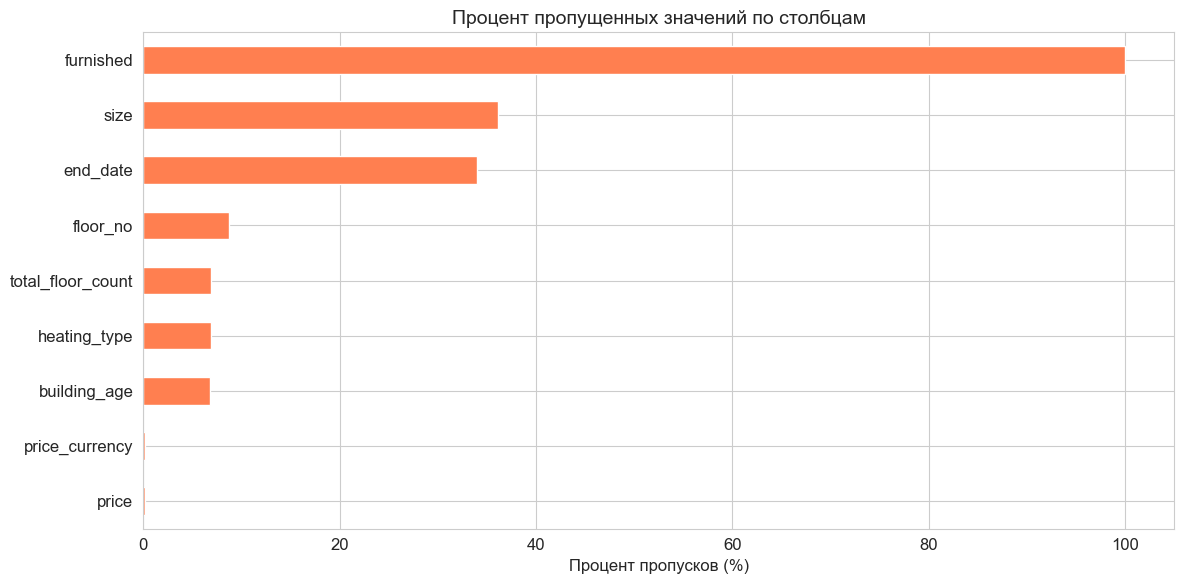

In [9]:
# Визуализация пропусков
plt.figure(figsize=(12, 6))
missing_pct[missing_pct > 0].sort_values().plot(kind='barh', color='coral')
plt.title('Процент пропущенных значений по столбцам', fontsize=14)
plt.xlabel('Процент пропусков (%)')
plt.tight_layout()
plt.show()

## Анализ целевой переменной price

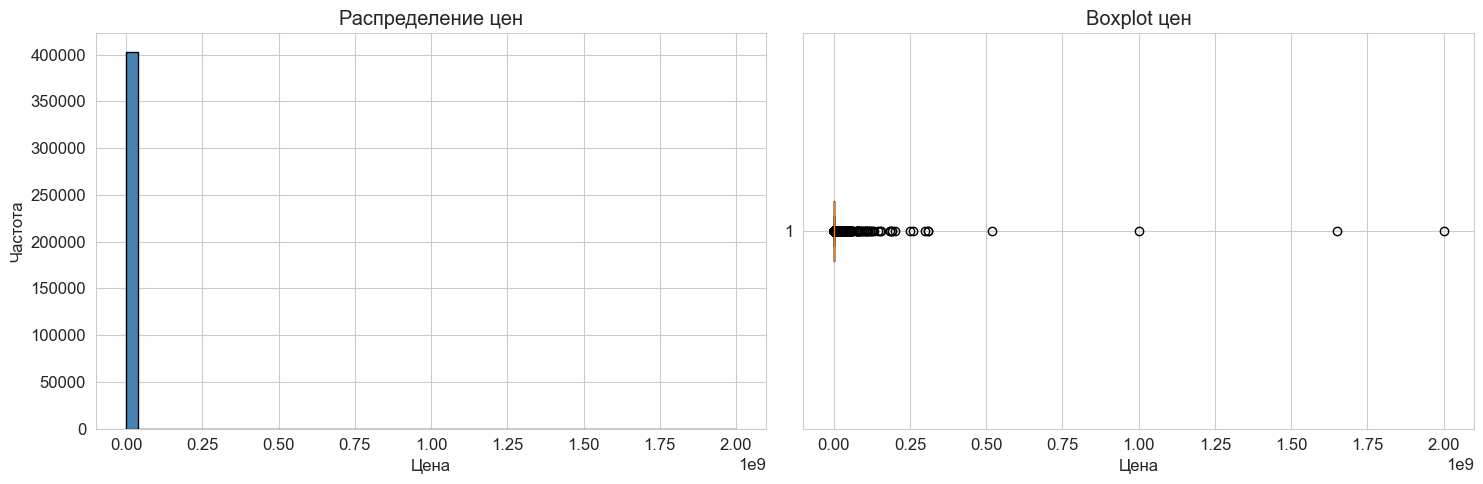

Асимметрия: 308.51
Эксцесс: 113739.59
Столбцов с ценой = 0: 44


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма
axes[0].hist(df['price'].dropna(), bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Распределение цен')
axes[0].set_xlabel('Цена')
axes[0].set_ylabel('Частота')

# Boxplot
axes[1].boxplot(df['price'].dropna(), vert=False)
axes[1].set_title('Boxplot цен')
axes[1].set_xlabel('Цена')

plt.tight_layout()
plt.show()

print(f"Асимметрия: {df['price'].skew():.2f}")
print(f"Эксцесс: {df['price'].kurtosis():.2f}")
print(f"Столбцов с ценой = 0: {(df['price'] == 0).sum()}")

Аналитический вывод:

Экстремальная правосторонняя асимметрия (skew = 308.51)

Огромный эксцесс (113739.59) — наличие тяжелых хвостов и выбросов

Обнаружены 2 записи с ценой = 0 (аномалия)

Требуется логарифмирование цены для нормализации распределения

Необходима фильтрация выбросов (например, цена > 99.9 перцентиля)

In [11]:
# Медианная цена по sub_type
price_by_subtype = df.groupby('sub_type')['price'].agg(['median', 'mean', 'count'])
price_by_subtype = price_by_subtype.sort_values('median', ascending=False)
print(price_by_subtype)

                        median          mean   count
sub_type                                            
Köşk / Konak / Yalı  2275000.0  1.905543e+07     300
Komple Bina           720000.0  2.288145e+06    2606
Villa                 675000.0  1.235608e+06   21303
Çiftlik Evi           649500.0  2.005875e+06     526
Loft                  457500.0  7.017662e+05      34
Yazlık                358000.0  4.168311e+05    5929
Müstakil Ev           350000.0  6.274828e+05    9546
Rezidans              230000.0  7.459829e+05    7691
Daire                 185000.0  2.515976e+05  353905
Kooperatif            142000.0  2.081929e+05      70
Prefabrik Ev           68745.0  8.480468e+04     676
Yalı Dairesi           40000.0  2.402333e+06     186


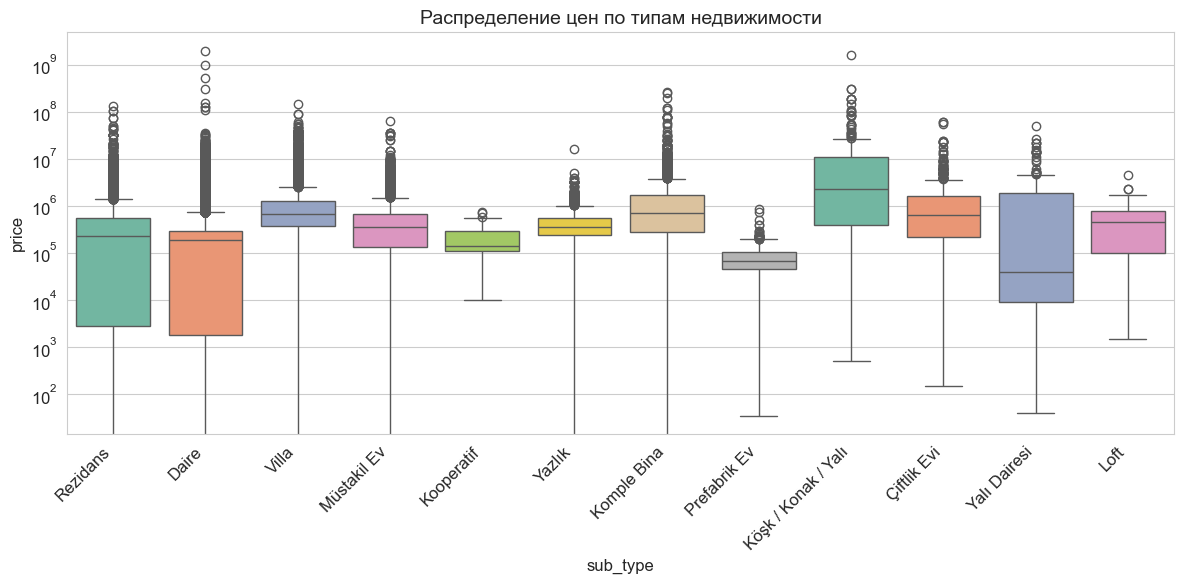

In [12]:
# Визуализация
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='sub_type', y='price', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Распределение цен по типам недвижимости', fontsize=14)
plt.yscale('log')
plt.tight_layout()
plt.show()

Аналитический вывод:

Самые дорогие: Köşk/Konak/Yalı , Komple Bina , Villa 

Самые доступные: Yazlık, Daire 

Rezidans показывает наибольший разброс — от доступных до премиум

Логарифмическая шкала выявляет выбросы во всех категориях



In [13]:
# Извлечение города из адреса
df['city'] = df['address'].str.split('/').str[0]

city_stats = df.groupby('city')['price'].agg(['median', 'count'])
city_stats = city_stats[city_stats['count'] >= 50].sort_values('median', ascending=False)

print(city_stats.head(10))

              median  count
city                       
Siirt       654321.0     52
Muğla       335000.0  11583
Aydın       280000.0  34619
Diyarbakır  265000.0    223
İzmir       255000.0  27694
Elazığ      249500.0    558
Van         238099.0    164
Balıkesir   235000.0  13176
Adıyaman    228000.0   1024
Aksaray     225000.0   1283


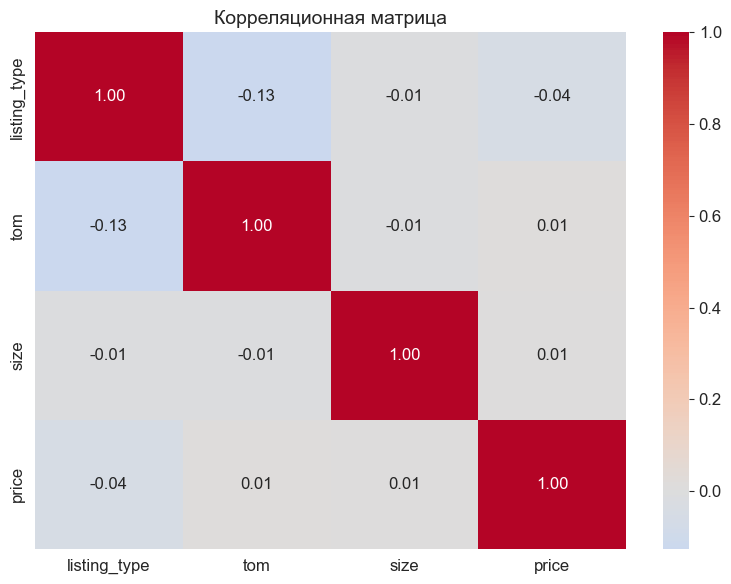

              listing_type       tom      size     price
listing_type      1.000000 -0.126534 -0.010385 -0.044270
tom              -0.126534  1.000000 -0.011847  0.011818
size             -0.010385 -0.011847  1.000000  0.005889
price            -0.044270  0.011818  0.005889  1.000000


In [14]:
# Выбор числовых столбцов
numeric_df = df[['listing_type', 'tom', 'size', 'price']].copy()

# Корреляционная матрица
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляционная матрица', fontsize=14)
plt.tight_layout()
plt.show()

print(corr_matrix)

In [15]:
# Парсинг дат
df['start_date_parsed'] = pd.to_datetime(df['start_date'], format='%m/%d/%y', errors='coerce')
df['month'] = df['start_date_parsed'].dt.to_period('M')

monthly_stats = df.groupby('month').agg({
    'id': 'count',
    'price': 'median'
}).rename(columns={'id': 'listings_count', 'price': 'median_price'})

print(monthly_stats)

         listings_count  median_price
month                                
2018-08            2755      198000.0
2018-09           80691      205000.0
2018-10           90424      210000.0
2018-11           77022      200000.0
2018-12           59035      190000.0
2019-01           48445      180000.0
2019-02           45115      198000.0


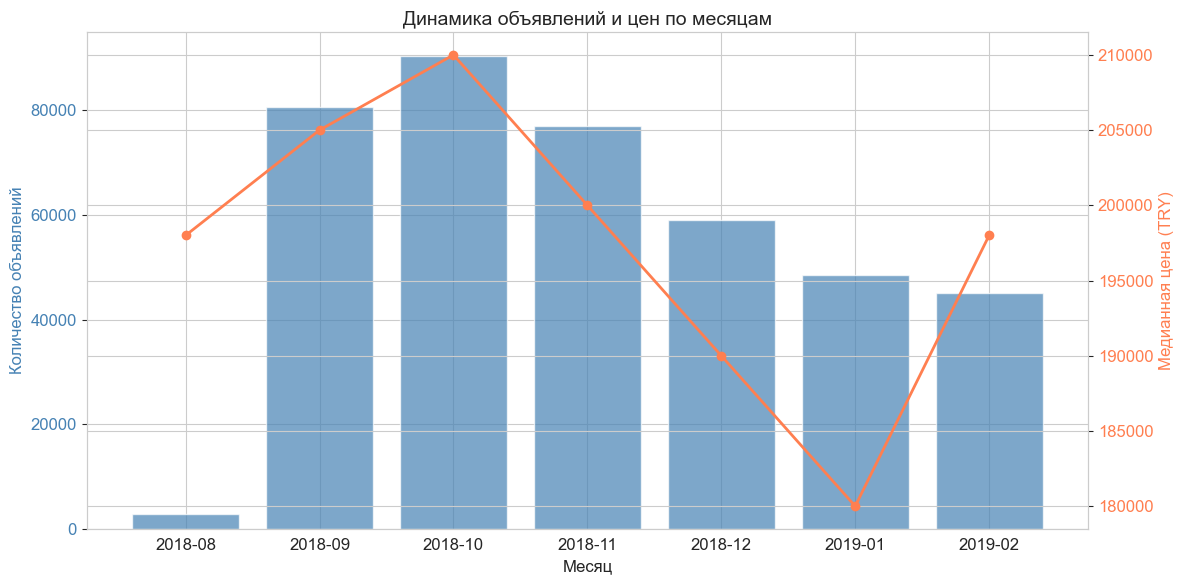

In [16]:
# Визуализация
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(monthly_stats.index.astype(str), monthly_stats['listings_count'], 
        color='steelblue', alpha=0.7, label='Количество объявлений')
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Количество объявлений', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(monthly_stats.index.astype(str), monthly_stats['median_price'], 
         color='coral', marker='o', linewidth=2, label='Медианная цена')
ax2.set_ylabel('Медианная цена (TRY)', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

plt.title('Динамика объявлений и цен по месяцам', fontsize=14)
plt.tight_layout()
plt.show()

## Визуальный анализ

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

df = pd.read_csv('real_estate_data.csv')
print(f"Размер: {df.shape}")

# Парсинг size
df['size'] = pd.to_numeric(df['size'], errors='coerce')

# Извлечение числового значения комнат (2+1 -> 3)
def parse_rooms(x):
    if pd.isna(x): return np.nan
    parts = str(x).split('+')
    try:
        return sum(int(p) for p in parts if p.strip().isdigit())
    except:
        return np.nan

df['room_total'] = df['room_count'].apply(parse_rooms)

# Извлечение города и района
df['city']    = df['address'].str.split('/').str[0].str.strip()
df['district'] = df['address'].str.split('/').str[1].str.strip()

# Фильтрация аномалий для визуализации
df_clean = df[(df['price'] > 0) & (df['price'] < df['price'].quantile(0.999))].copy()
print(f"После фильтрации выбросов: {len(df_clean):,}")

Размер: (403487, 17)
После фильтрации выбросов: 402,311


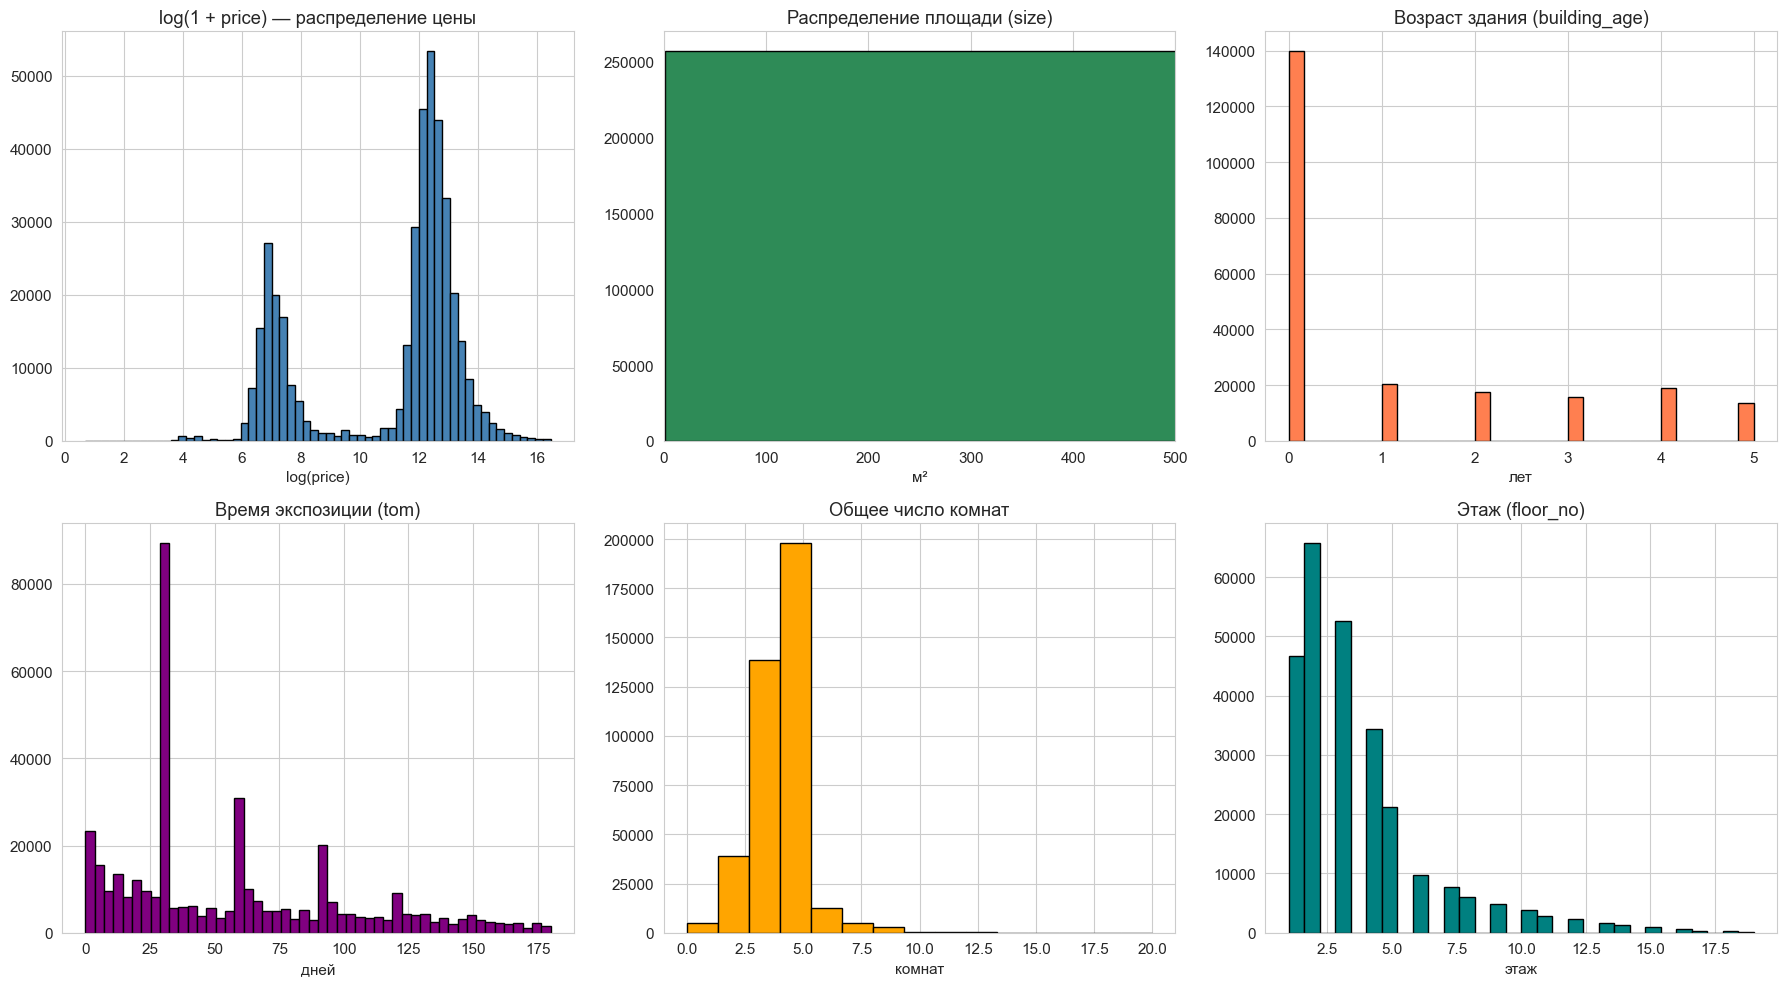

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Распределение цены (log-шкала)
axes[0,0].hist(np.log1p(df_clean['price']), bins=60, color='steelblue', edgecolor='black')
axes[0,0].set_title('log(1 + price) — распределение цены')
axes[0,0].set_xlabel('log(price)')

# 2. Распределение площади
axes[0,1].hist(df_clean['size'].dropna(), bins=60, color='seagreen', edgecolor='black')
axes[0,1].set_title('Распределение площади (size)')
axes[0,1].set_xlabel('м²')
axes[0,1].set_xlim(0, 500)

# 3. Распределение возраста здания
age_num = pd.to_numeric(df_clean['building_age'], errors='coerce')
axes[0,2].hist(age_num.dropna(), bins=30, color='coral', edgecolor='black')
axes[0,2].set_title('Возраст здания (building_age)')
axes[0,2].set_xlabel('лет')

# 4. Распределение TOM (time on market)
axes[1,0].hist(df_clean['tom'], bins=50, color='purple', edgecolor='black')
axes[1,0].set_title('Время экспозиции (tom)')
axes[1,0].set_xlabel('дней')

# 5. Распределение числа комнат
axes[1,1].hist(df_clean['room_total'].dropna(), bins=15, color='orange', edgecolor='black')
axes[1,1].set_title('Общее число комнат')
axes[1,1].set_xlabel('комнат')

# 6. Распределение этажа
floor_num = pd.to_numeric(df_clean['floor_no'], errors='coerce')
axes[1,2].hist(floor_num.dropna(), bins=30, color='teal', edgecolor='black')
axes[1,2].set_title('Этаж (floor_no)')
axes[1,2].set_xlabel('этаж')

plt.tight_layout()
plt.show()

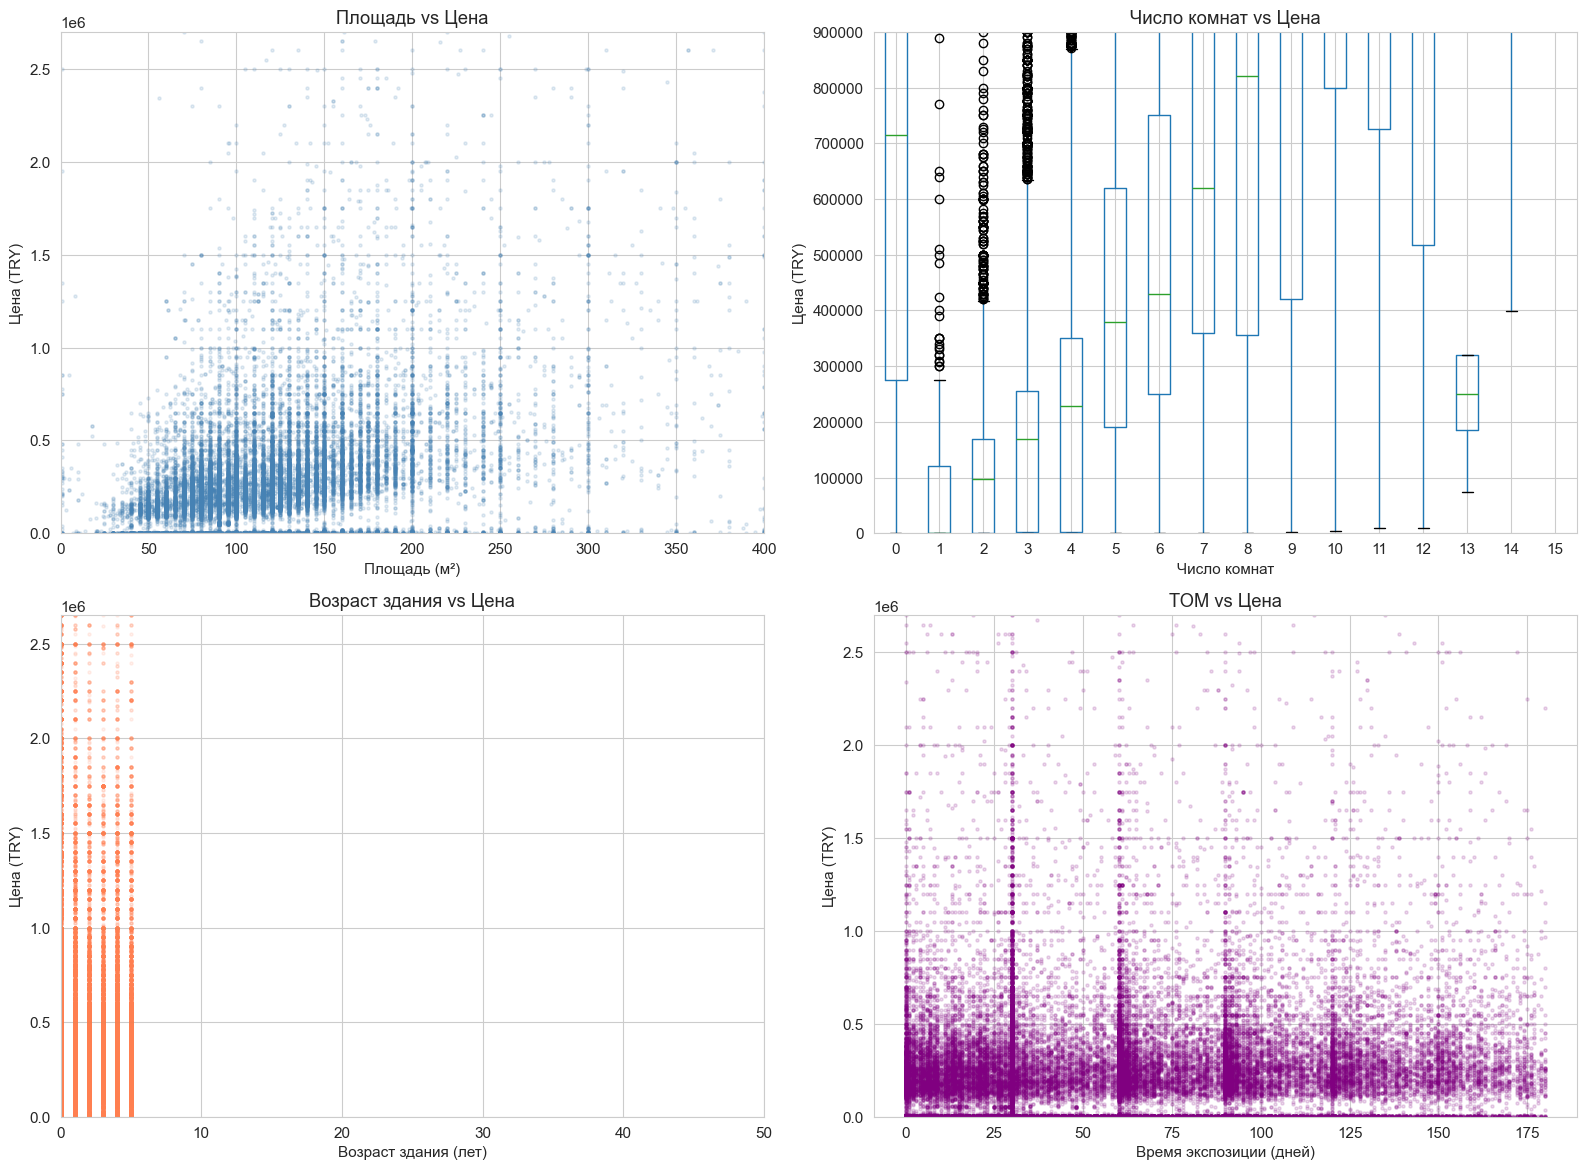

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Сэмплирование для скорости (50k точек)
sample = df_clean.sample(n=min(50000, len(df_clean)), random_state=42)

# 1. size vs price
axes[0,0].scatter(sample['size'], sample['price'], alpha=0.15, s=5, color='steelblue')
axes[0,0].set_xlabel('Площадь (м²)')
axes[0,0].set_ylabel('Цена (TRY)')
axes[0,0].set_title('Площадь vs Цена')
axes[0,0].set_xlim(0, 400)
axes[0,0].set_ylim(0, sample['price'].quantile(0.99))

# 2. room_total vs price (boxplot)
sample.boxplot(column='price', by='room_total', ax=axes[0,1])
axes[0,1].set_xlabel('Число комнат')
axes[0,1].set_ylabel('Цена (TRY)')
axes[0,1].set_title('Число комнат vs Цена')
axes[0,1].set_ylim(0, sample['price'].quantile(0.95))
plt.sca(axes[0,1]); plt.title('Число комнат vs Цена'); plt.suptitle('')

# 3. building_age vs price
axes[1,0].scatter(age_num, df_clean['price'], alpha=0.1, s=5, color='coral')
axes[1,0].set_xlabel('Возраст здания (лет)')
axes[1,0].set_ylabel('Цена (TRY)')
axes[1,0].set_title('Возраст здания vs Цена')
axes[1,0].set_ylim(0, df_clean['price'].quantile(0.99))
axes[1,0].set_xlim(0, 50)

# 4. tom vs price
axes[1,1].scatter(sample['tom'], sample['price'], alpha=0.15, s=5, color='purple')
axes[1,1].set_xlabel('Время экспозиции (дней)')
axes[1,1].set_ylabel('Цена (TRY)')
axes[1,1].set_title('TOM vs Цена')
axes[1,1].set_ylim(0, sample['price'].quantile(0.99))

plt.tight_layout()
plt.show()

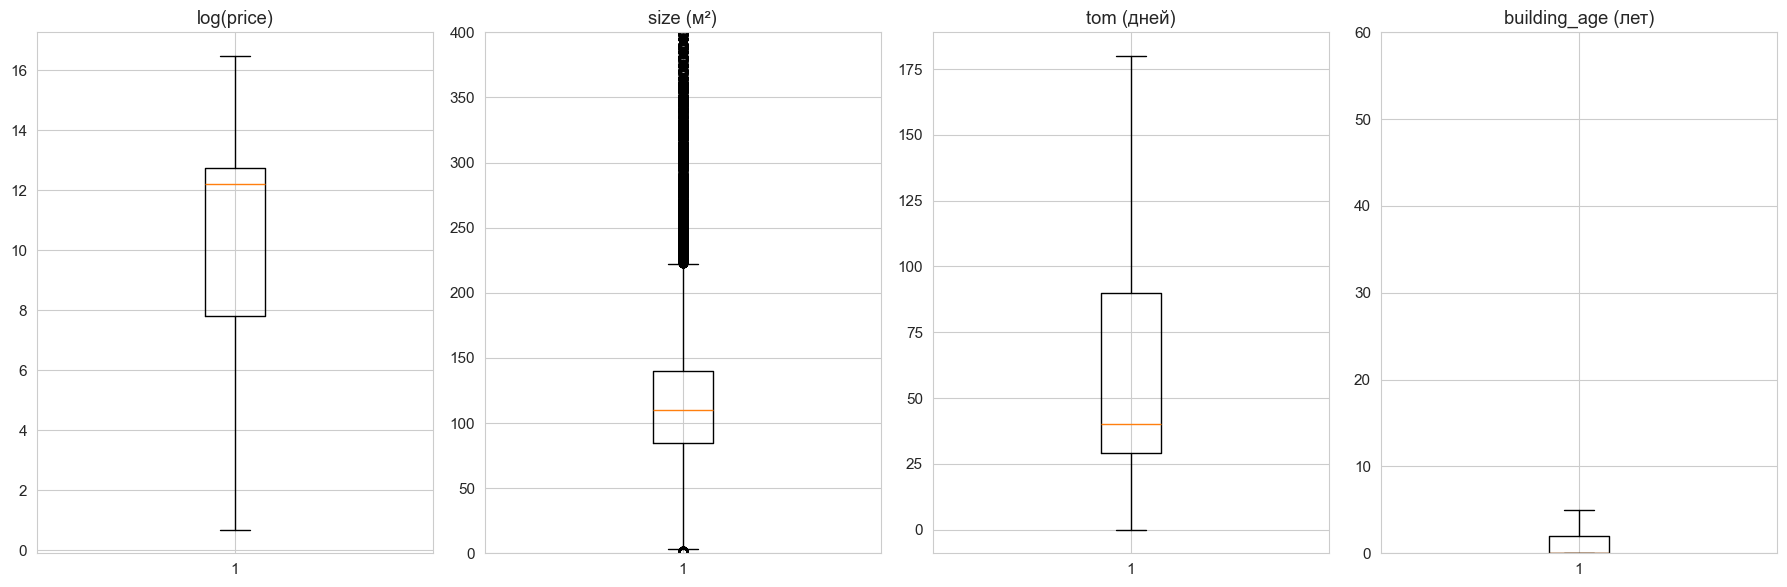

Количество выбросов (IQR):
  price:         22,839 (5.68%)
  size:          13,724
  tom:                0
  building_age:       0


In [20]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# Логарифмированные значения для читаемости
axes[0].boxplot(np.log1p(df_clean['price'].dropna()), vert=True)
axes[0].set_title('log(price)')

axes[1].boxplot(df_clean['size'].dropna(), vert=True)
axes[1].set_title('size (м²)')
axes[1].set_ylim(0, 400)

axes[2].boxplot(df_clean['tom'].dropna(), vert=True)
axes[2].set_title('tom (дней)')

axes[3].boxplot(age_num.dropna(), vert=True)
axes[3].set_title('building_age (лет)')
axes[3].set_ylim(0, 60)

plt.tight_layout()
plt.show()

# Количественная оценка выбросов (метод IQR)
def outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)).sum()

print("Количество выбросов (IQR):")
print(f"  price:        {outliers_iqr(df_clean['price']):>7,} ({outliers_iqr(df_clean['price'])/len(df_clean)*100:.2f}%)")
print(f"  size:         {outliers_iqr(df_clean['size'].dropna()):>7,}")
print(f"  tom:          {outliers_iqr(df_clean['tom']):>7,}")
print(f"  building_age: {outliers_iqr(age_num.dropna()):>7,}")

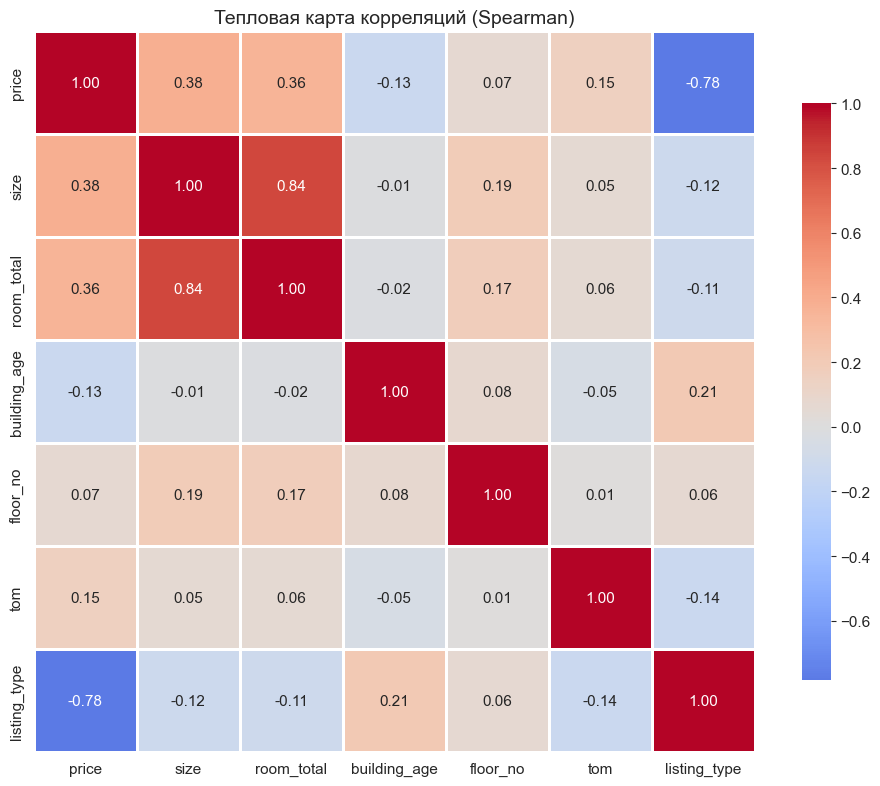

price           1.000000
size            0.380989
room_total      0.357384
tom             0.151583
floor_no        0.068951
building_age   -0.131655
listing_type   -0.783588
Name: price, dtype: float64


In [21]:
# Формирование числового датафрейма
numeric_df = pd.DataFrame({
    'price':        df_clean['price'],
    'size':         df_clean['size'],
    'room_total':   df_clean['room_total'],
    'building_age': age_num,
    'floor_no':     pd.to_numeric(df_clean['floor_no'], errors='coerce'),
    'tom':          df_clean['tom'],
    'listing_type': df_clean['listing_type']
})

corr = numeric_df.corr(method='spearman')  # Спирмен — устойчив к выбросам

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Тепловая карта корреляций (Spearman)', fontsize=14)
plt.tight_layout()
plt.show()

print(corr['price'].sort_values(ascending=False))

Категориальные признаки vs Цена (bar chart средних/медианных цен)

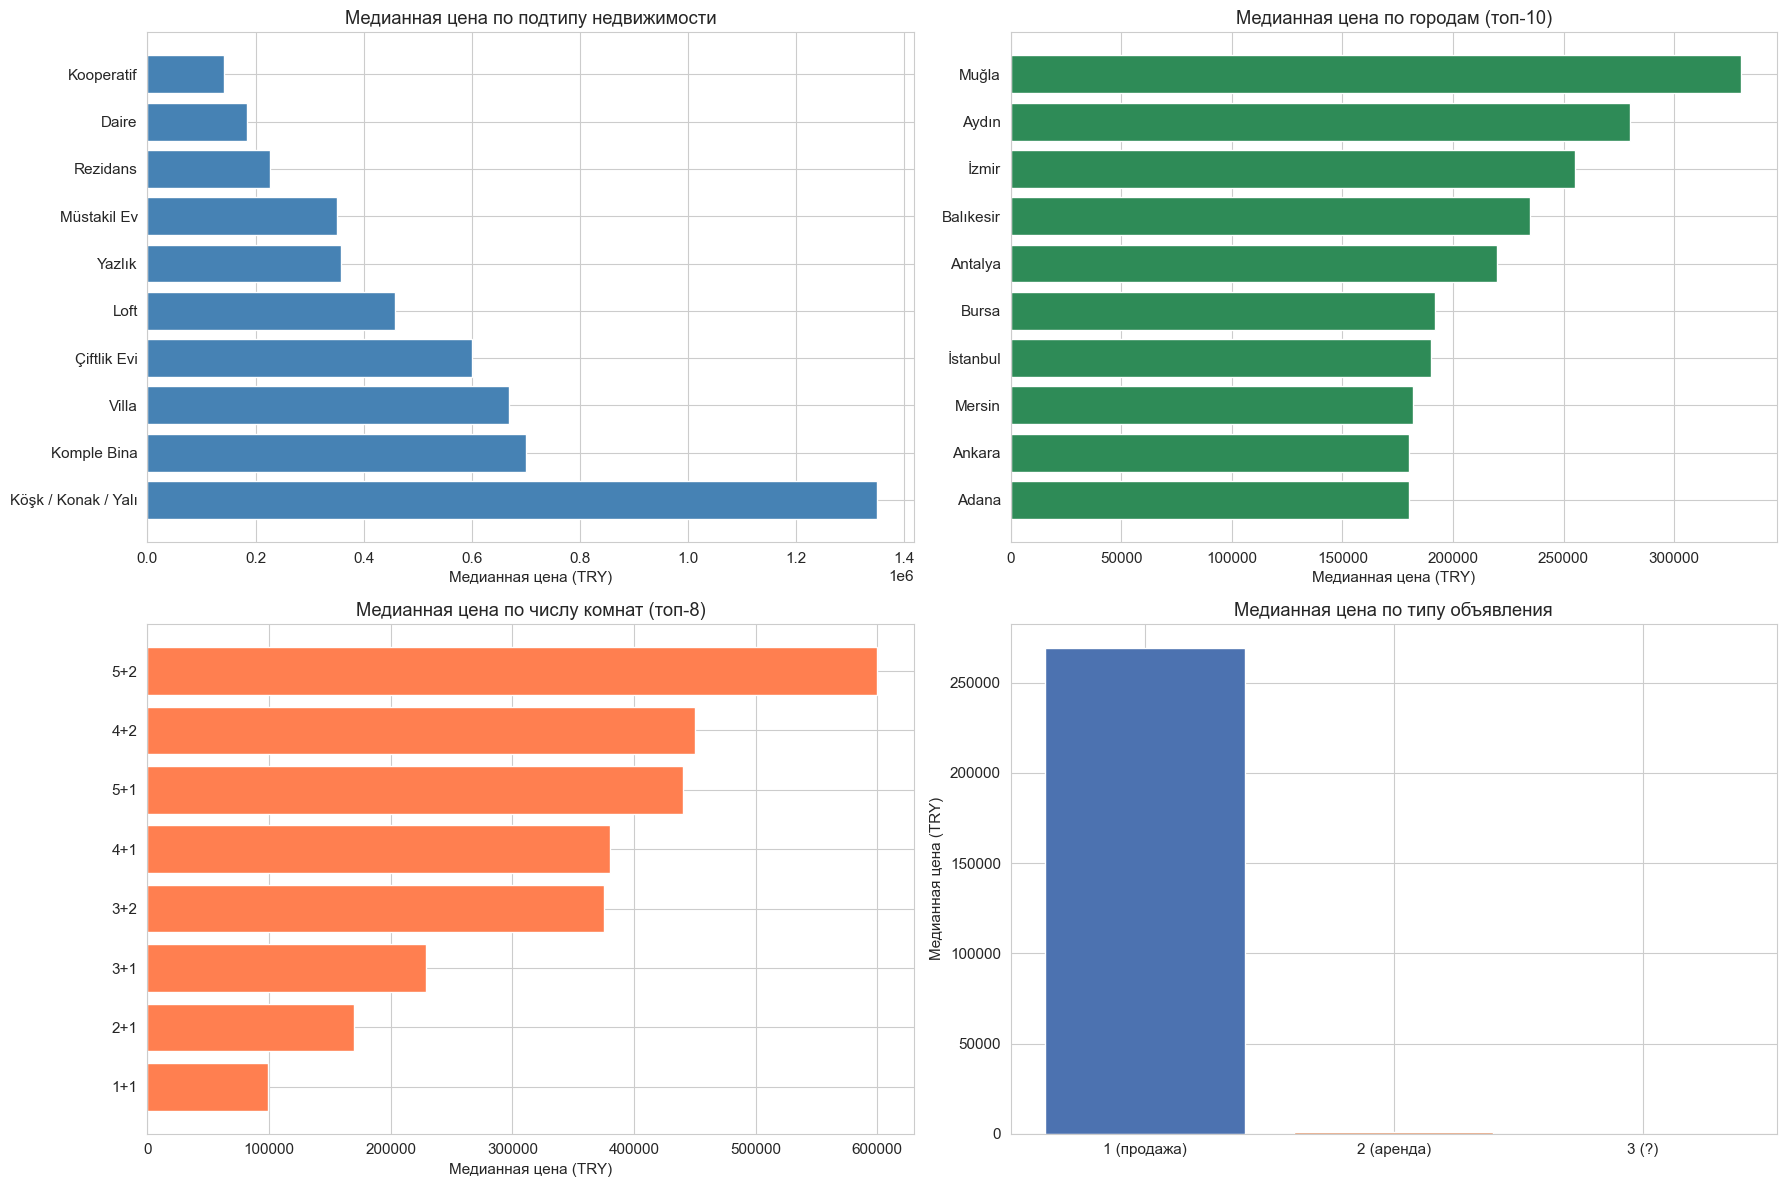


Медианная цена по типу отопления:
                                   median   count
heating_type                                     
Fancoil                          500000.0     476
Güneş Enerjisi                   228000.0    1750
Jeotermal                        215000.0    1418
Kalorifer (Akaryakıt)            335000.0     404
Kalorifer (Doğalgaz)             185000.0   10896
Kalorifer (Kömür)                175000.0    1501
Kat Kaloriferi                   310000.0    5632
Klima                            245000.0   68133
Kombi (Doğalgaz)                 185000.0  203703
Kombi (Elektrikli)               240000.0    3448
Merkezi Sistem                   190000.0   22775
Merkezi Sistem (Isı Payı Ölçer)  255000.0   30570
Soba (Doğalgaz)                  140000.0    2597
Soba (Kömür)                     135000.0    8443
Yerden Isıtma                    340000.0    6930
Yok                              185000.0    6088


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. sub_type
sub_stats = df_clean.groupby('sub_type')['price'].median().sort_values(ascending=False).head(10)
axes[0,0].barh(sub_stats.index, sub_stats.values, color='steelblue')
axes[0,0].set_title('Медианная цена по подтипу недвижимости')
axes[0,0].set_xlabel('Медианная цена (TRY)')

# 2. city (топ-10 по количеству)
top_cities = df_clean['city'].value_counts().head(10).index
city_stats = df_clean[df_clean['city'].isin(top_cities)].groupby('city')['price'].median().sort_values()
axes[0,1].barh(city_stats.index, city_stats.values, color='seagreen')
axes[0,1].set_title('Медианная цена по городам (топ-10)')
axes[0,1].set_xlabel('Медианная цена (TRY)')

# 3. room_count (топ-8)
top_rooms = df_clean['room_count'].value_counts().head(8).index
room_stats = df_clean[df_clean['room_count'].isin(top_rooms)].groupby('room_count')['price'].median().sort_values()
axes[1,0].barh(room_stats.index, room_stats.values, color='coral')
axes[1,0].set_title('Медианная цена по числу комнат (топ-8)')
axes[1,0].set_xlabel('Медианная цена (TRY)')

# 4. listing_type
lt_stats = df_clean.groupby('listing_type')['price'].median()
axes[1,1].bar(['1 (продажа)', '2 (аренда)', '3 (?)'], 
              [lt_stats.get(1,0), lt_stats.get(2,0), lt_stats.get(3,0)],
              color=['#4C72B0','#DD8452','#55A868'])
axes[1,1].set_title('Медианная цена по типу объявления')
axes[1,1].set_ylabel('Медианная цена (TRY)')

plt.tight_layout()
plt.show()

# Таблица средних цен по heating_type
print("\nМедианная цена по типу отопления:")
print(df_clean.groupby('heating_type')['price'].agg(['median','count']))

## Анализ пропусков и аномалий

In [23]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100)

missing_table = pd.DataFrame({
    'Пропущено': missing,
    'Доля (%)': missing_pct.round(2),
    'Тип': df.dtypes.astype(str)
}).sort_values('Доля (%)', ascending=False)

print(missing_table[missing_table['Пропущено'] > 0])

                   Пропущено  Доля (%)      Тип
furnished             403487    100.00  float64
size                  146006     36.19  float64
end_date              137189     34.00   object
floor_no               35296      8.75   object
total_floor_count      28021      6.94   object
heating_type           27970      6.93   object
building_age           27390      6.79   object
price_currency           715      0.18   object
price                    715      0.18  float64
district                   7      0.00   object


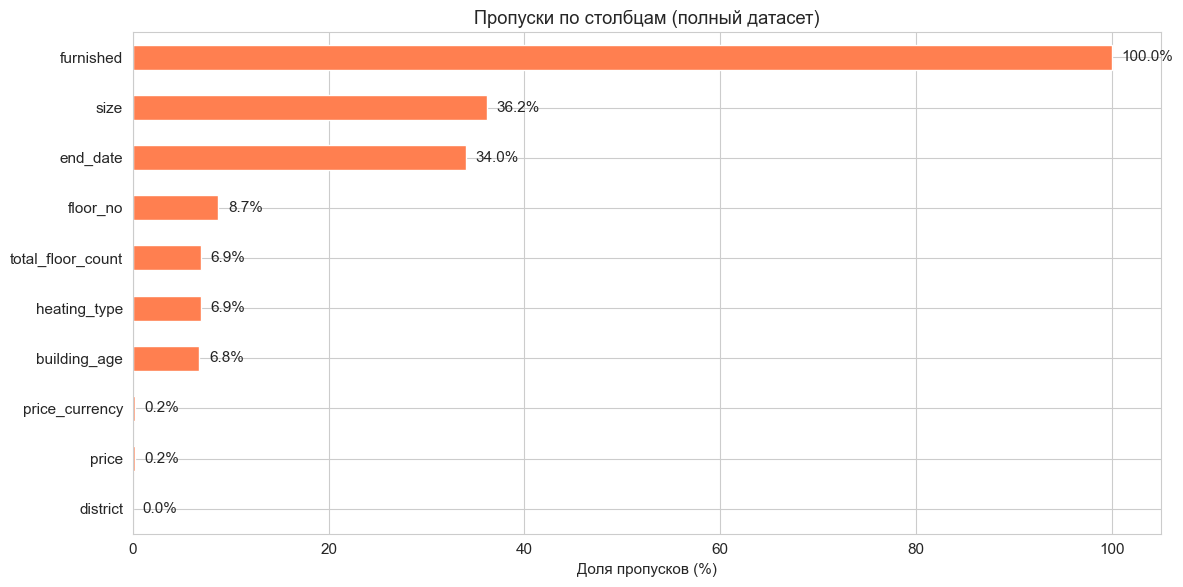

In [24]:
# Визуализация
fig, ax = plt.subplots(figsize=(12, 6))
missing_pct[missing_pct > 0].sort_values().plot(kind='barh', color='coral', ax=ax)
ax.set_xlabel('Доля пропусков (%)')
ax.set_title('Пропуски по столбцам (полный датасет)')
for i, v in enumerate(missing_pct[missing_pct > 0].sort_values()):
    ax.text(v + 1, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

## Проверка дубликатов

In [25]:
# Полные дубликаты
full_dups = df.duplicated().sum()

# Дубликаты по ключевым признакам (без id)
key_cols = [c for c in df.columns if c != 'id']
key_dups = df.duplicated(subset=key_cols).sum()

# Дубликаты по адресу + цене + площади
biz_dups = df.duplicated(subset=['address', 'price', 'size']).sum()

print(f"Полные дубликаты:                          {full_dups:,}")
print(f"Дубликаты по всем признакам (кроме id):    {key_dups:,}")
print(f"Дубликаты по (address, price, size):       {biz_dups:,}")

Полные дубликаты:                          0
Дубликаты по всем признакам (кроме id):    11,455
Дубликаты по (address, price, size):       157,993


## Логическая согласованность данных

In [26]:
print("ПРОВЕРКА ЛОГИЧЕСКОЙ СОГЛАСОВАННОСТИ")

# 1. Отрицательные цены
neg_price = (df['price'] < 0).sum()
print(f"\n1. Отрицательные цены:                  {neg_price}")

# 2. Нулевые цены
zero_price = (df['price'] == 0).sum()
print(f"2. Нулевые цены:                        {zero_price}")

# 3. Нереалистичные цены (> 100 млн TRY)
huge_price = (df['price'] > 100_000_000).sum()
print(f"3. Цены > 100 млн TRY:                  {huge_price}")

# 4. Отрицательная площадь
neg_size = (df['size'] < 0).sum()
print(f"4. Отрицательная площадь:               {neg_size}")

# 5. Нереалистичная площадь (> 10,000 м²)
huge_size = (df['size'] > 10_000).sum()
print(f"5. Площадь > 10,000 м²:                 {huge_size}")

# 6. Возраст здания > 200 лет
age_num_check = pd.to_numeric(df['building_age'], errors='coerce')
huge_age = (age_num_check > 200).sum()
print(f"6. Возраст здания > 200 лет:            {huge_age}")

# 7. Отрицательный возраст
neg_age = (age_num_check < 0).sum()
print(f"7. Отрицательный возраст здания:        {neg_age}")

# 8. Этаж > общего числа этажей
floor_num = pd.to_numeric(df['floor_no'], errors='coerce')
floor_total = pd.to_numeric(df['total_floor_count'], errors='coerce')
floor_inconsistent = ((floor_num > floor_total) & floor_total.notna() & floor_num.notna()).sum()
print(f"8. Этаж > общего числа этажей:          {floor_inconsistent}")

# 9. Цена за м² < 100 TRY (подозрительно дёшево)
df['price_per_sqm'] = df['price'] / df['size']
cheap_sqm = ((df['price_per_sqm'] < 100) & df['price_per_sqm'].notna()).sum()
print(f"9. Цена за м² < 100 TRY:                {cheap_sqm}")

# 10. Цена за м² > 1,000,000 TRY
expensive_sqm = (df['price_per_sqm'] > 1_000_000).sum()
print(f"10. Цена за м² > 1 млн TRY:             {expensive_sqm}")

# 11. listing_type вне диапазона {1,2,3}
invalid_lt = (~df['listing_type'].isin([1, 2, 3])).sum()
print(f"11. listing_type вне {{1,2,3}}:           {invalid_lt}")

# 12. start_date > end_date
start = pd.to_datetime(df['start_date'], format='%m/%d/%y', errors='coerce')
end   = pd.to_datetime(df['end_date'],   format='%m/%d/%y', errors='coerce')
date_inconsistent = ((start > end) & start.notna() & end.notna()).sum()
print(f"12. start_date > end_date:              {date_inconsistent}")

ПРОВЕРКА ЛОГИЧЕСКОЙ СОГЛАСОВАННОСТИ

1. Отрицательные цены:                  1
2. Нулевые цены:                        44
3. Цены > 100 млн TRY:                  28
4. Отрицательная площадь:               0
5. Площадь > 10,000 м²:                 148
6. Возраст здания > 200 лет:            0
7. Отрицательный возраст здания:        0
8. Этаж > общего числа этажей:          1387
9. Цена за м² < 100 TRY:                71172
10. Цена за м² > 1 млн TRY:             37
11. listing_type вне {1,2,3}:           0
12. start_date > end_date:              0


In [27]:
# Поэтапная диагностика потерь
print("ДИАГНОСТИКА ПОТЕРЬ ДАННЫХ")

n0 = len(df)
print(f"\nИсходный размер:                         {n0:,}")

# Шаг 1: furnished (не влияет на размер)
df1 = df.drop(columns=['furnished'])
print(f"После удаления furnished:                {len(df1):,} (-0)")

# Шаг 2: аномальные цены
mask_price = (df1['price'] > 0) & (df1['price'] < 100_000_000)
lost_price = (~mask_price).sum()
print(f"Аномальные цены:                         -{lost_price:,}")

# Шаг 3: аномальные размеры
df2 = df1[mask_price]
mask_size = (df2['size'] > 0) & (df2['size'] < 10_000)
lost_size = (~mask_size & df2['size'].notna()).sum()
print(f"Аномальные размеры:                      -{lost_size:,}")

# Шаг 4: дубликаты (ГЛАВНАЯ ПРИЧИНА ПОТЕРЬ!)
df3 = df2[mask_size]
key_cols = ['address', 'price', 'size', 'room_count', 'listing_type']
dups = df3.duplicated(subset=key_cols).sum()
print(f"Дубликаты по {key_cols}:")
print(f"                                         -{dups:,}  ← ГЛАВНАЯ ПРИЧИНА")

ДИАГНОСТИКА ПОТЕРЬ ДАННЫХ

Исходный размер:                         403,487
После удаления furnished:                403,487 (-0)
Аномальные цены:                         -790
Аномальные размеры:                      -154
Дубликаты по ['address', 'price', 'size', 'room_count', 'listing_type']:
                                         -80,388  ← ГЛАВНАЯ ПРИЧИНА


In [28]:
# Посмотрим на примере конкретного "дубликата"
sample_dup = df3[df3.duplicated(subset=key_cols, keep=False)].head(10)

print("Пример строк, которые считаются дубликатами:")
print(sample_dup[['id', 'address', 'price', 'size', 'room_count', 
                  'start_date', 'end_date', 'tom', 'listing_type']].to_string())

Пример строк, которые считаются дубликатами:
    id                     address       price   size room_count start_date  end_date  tom  listing_type
0    1  İstanbul/Kartal/Kordonboyu      3500.0   90.0        2+1   12/10/18    1/9/19   30             2
3    4    İstanbul/Beşiktaş/Levent  32500000.0  450.0        6+1    9/10/18  10/10/18   30             1
4    5  İstanbul/Kartal/Kordonboyu   1450000.0   90.0        2+1   12/10/18    1/9/19   30             1
15  16         İzmir/Urla/Çamlıçay      3600.0  200.0        4+1    10/2/18    1/4/19   94             2
16  17        İstanbul/Şişli/İnönü   3800000.0   85.0        1+1    11/9/18   12/9/18   30             1
17  18  İstanbul/Kartal/Kordonboyu      4200.0   84.0        2+1   12/10/18    1/9/19   30             2
19  20    İstanbul/Beşiktaş/Levent  32500000.0  450.0        6+1    9/10/18   2/11/19  154             1
23  24  Mersin/Yenişehir/Afetevler      1100.0  100.0        2+1   11/23/18   1/14/19   52             2
26  27    

In [29]:
# Принцип: удаляем только безнадежные строки, остальное — исправляем

df_clean_v2 = df.copy()
n_start = len(df_clean_v2)

print("="*60)
print("МЯГКАЯ ОЧИСТКА ДАННЫХ (v2)")
print("="*60)
print(f"\nСтарт: {n_start:,} строк")

# --- ШАГ 1: Удалить бесполезный столбец ---
df_clean_v2 = df_clean_v2.drop(columns=['furnished'], errors='ignore')
print(f"\n[1] Удалён столбец 'furnished' (100% пропусков)")

# --- ШАГ 2: Исправление цен (вместо удаления) ---
# Отрицательные → NaN (заполним позже медианой)
neg_price = (df_clean_v2['price'] < 0).sum()
df_clean_v2.loc[df_clean_v2['price'] < 0, 'price'] = np.nan

# Нулевые → NaN
zero_price = (df_clean_v2['price'] == 0).sum()
df_clean_v2.loc[df_clean_v2['price'] == 0, 'price'] = np.nan

# Экстремальные (> 100 млн) → NaN (выбросы)
huge_price = (df_clean_v2['price'] > 100_000_000).sum()
df_clean_v2.loc[df_clean_v2['price'] > 100_000_000, 'price'] = np.nan

print(f"[2] Цены: исправлено {neg_price} отрицательных, {zero_price} нулевых, {huge_price} экстремальных")

# --- ШАГ 3: Исправление размеров ---
neg_size = (df_clean_v2['size'] < 0).sum()
df_clean_v2.loc[df_clean_v2['size'] < 0, 'size'] = np.nan

huge_size = (df_clean_v2['size'] > 10_000).sum()
df_clean_v2.loc[df_clean_v2['size'] > 10_000, 'size'] = np.nan

print(f"[3] Размеры: исправлено {neg_size} отрицательных, {huge_size} экстремальных")

# --- ШАГ 4: Умная дедупликация ---
# Оставляем ТОЛЬКО истинные дубликаты (все признаки кроме id идентичны)
key_cols_strict = ['address', 'price', 'size', 'room_count', 
                   'listing_type', 'start_date', 'end_date', 'tom']
before = len(df_clean_v2)
df_clean_v2 = df_clean_v2.drop_duplicates(subset=key_cols_strict, keep='first')
strict_dups = before - len(df_clean_v2)

print(f"[4] Строгие дубликаты (все признаки): удалено {strict_dups:,}")

# --- ШАГ 5: Заполнение пропусков (умное) ---
# size: медиана по sub_type
size_missing = df_clean_v2['size'].isnull().sum()
df_clean_v2['size'] = df_clean_v2.groupby('sub_type')['size'].transform(
    lambda x: x.fillna(x.median())
)

# price: медиана по (sub_type, listing_type)
price_missing = df_clean_v2['price'].isnull().sum()
df_clean_v2['price'] = df_clean_v2.groupby(['sub_type', 'listing_type'])['price'].transform(
    lambda x: x.fillna(x.median())
)
# Остатки — глобальная медиана
df_clean_v2['price'] = df_clean_v2['price'].fillna(df_clean_v2['price'].median())
df_clean_v2['size']  = df_clean_v2['size'].fillna(df_clean_v2['size'].median())

print(f"[5] Заполнено пропусков: size={size_missing:,}, price={price_missing:,}")

# --- ШАГ 6: Финальная проверка ---
print(f"\n{'='*60}")
print(f"ИТОГ: {len(df_clean_v2):,} строк ({len(df_clean_v2)/n_start*100:.1f}% сохранено)")
print(f"Потеряно: {n_start - len(df_clean_v2):,} строк ({(n_start-len(df_clean_v2))/n_start*100:.1f}%)")
print(f"{'='*60}")

МЯГКАЯ ОЧИСТКА ДАННЫХ (v2)

Старт: 403,487 строк

[1] Удалён столбец 'furnished' (100% пропусков)
[2] Цены: исправлено 1 отрицательных, 44 нулевых, 28 экстремальных
[3] Размеры: исправлено 0 отрицательных, 148 экстремальных
[4] Строгие дубликаты (все признаки): удалено 14,104
[5] Заполнено пропусков: size=140,653, price=513

ИТОГ: 389,383 строк (96.5% сохранено)
Потеряно: 14,104 строк (3.5%)


In [30]:
def prepare_real_estate_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    n_start = len(df)
    
    # ---- 1. Удаление бесполезных столбцов ----
    df = df.drop(columns=['furnished'], errors='ignore')
    
    # ---- 2. Приведение типов ----
    df['size'] = pd.to_numeric(df['size'], errors='coerce')
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['start_date'] = pd.to_datetime(df['start_date'], format='%m/%d/%y', errors='coerce')
    df['end_date']   = pd.to_datetime(df['end_date'],   format='%m/%d/%y', errors='coerce')
    
    # ---- 3. Исправление аномальных цен ----
    df.loc[df['price'] <= 0, 'price'] = np.nan
    df.loc[df['price'] > 100_000_000, 'price'] = np.nan
    
    # ---- 4. Исправление аномальных размеров ----
    df.loc[df['size'] <= 0, 'size'] = np.nan
    df.loc[df['size'] > 10_000, 'size'] = np.nan
    
    # ---- 5. Умная дедупликация (только истинные дубликаты) ----
    strict_keys = ['address', 'price', 'size', 'room_count', 
                   'listing_type', 'start_date', 'end_date', 'tom']
    df = df.drop_duplicates(subset=strict_keys, keep='first')
    
    # ---- 6. Feature engineering ----
    df['city'] = df['address'].str.split('/').str[0].str.strip()
    df['district'] = df['address'].str.split('/').str[1].str.strip()
    df['price_per_sqm'] = df['price'] / df['size']
    
    # ---- 7. Заполнение пропусков ----
    # size: медиана по sub_type
    df['size'] = df.groupby('sub_type')['size'].transform(
        lambda x: x.fillna(x.median())
    )
    df['size'] = df['size'].fillna(df['size'].median())
    
    # price: медиана по (sub_type, listing_type)
    df['price'] = df.groupby(['sub_type', 'listing_type'])['price'].transform(
        lambda x: x.fillna(x.median())
    )
    df['price'] = df['price'].fillna(df['price'].median())
    
    # ---- 8. Удаление финальных "безнадежных" строк ----
    df = df.dropna(subset=['price', 'size'])
    
    # ---- 9. Отчет ----
    n_final = len(df)
    print(f"   Pipeline завершён")
    print(f"   Начало:  {n_start:,} строк")
    print(f"   Конец:   {n_final:,} строк")
    print(f"   Сохранено: {n_final/n_start*100:.2f}%")
    print(f"   Потеряно:  {n_start - n_final:,} строк ({(n_start-n_final)/n_start*100:.2f}%)")
    
    return df


# Применение
df_final = prepare_real_estate_data('real_estate_data.csv')

   Pipeline завершён
   Начало:  403,487 строк
   Конец:   389,383 строк
   Сохранено: 96.50%
   Потеряно:  14,104 строк (3.50%)


In [31]:
# Разбивка по квартилям площади
df_clean['size_quartile'] = pd.qcut(df_clean['size'], 4, labels=['Q1 (малые)', 'Q2', 'Q3', 'Q4 (большие)'])
print(df_clean.groupby('size_quartile')['price'].median())

size_quartile
Q1 (малые)      136000.0
Q2              175000.0
Q3              219000.0
Q4 (большие)    357000.0
Name: price, dtype: float64


## Диагностика скошенности признаков

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('real_estate_data.csv')
df['size']  = pd.to_numeric(df['size'],  errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['building_age_num'] = pd.to_numeric(df['building_age'], errors='coerce')

# Оценка асимметрии
def skew_report(series, name):
    s = series.dropna()
    return {
        'Признак': name,
        'Skewness': round(stats.skew(s), 3),
        'Kurtosis': round(stats.kurtosis(s), 3),
        'Min': s.min(),
        'Max': s.max(),
        '99.9%': s.quantile(0.999)
    }

report = pd.DataFrame([
    skew_report(df['price'], 'price'),
    skew_report(df['size'], 'size'),
    skew_report(df['building_age_num'], 'building_age'),
    skew_report(df['tom'], 'tom'),
])

print(report.to_string(index=False))

     Признак  Skewness   Kurtosis    Min          Max      99.9%
       price   308.506 113738.179 -250.0 2000000000.0 14500000.0
        size    77.653   6477.984    1.0     948235.0     3902.0
building_age     1.231      0.048    0.0          5.0        5.0
         tom     0.837     -0.228    0.0        180.0      180.0


## Применение винсоризации (Winsorization)

In [33]:
from scipy.stats.mstats import winsorize

df_clean = df.copy()

# --- Удаление безнадёжных строк ---
df_clean = df_clean.drop(columns=['furnished'], errors='ignore')
df_clean = df_clean[(df_clean['price'] > 0) & (df_clean['price'] < 100_000_000)]
df_clean = df_clean[(df_clean['size'] > 0)  & (df_clean['size'] < 10_000)]

print(f"После базовой очистки: {len(df_clean):,}")

# --- Винсоризация ---
def winsorize_column(series, lower=0.001, upper=0.999):
    """Ограничение значений по перцентилям"""
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lower=lo, upper=hi)

# price — экстремальные выбросы
df_clean['price_w'] = winsorize_column(df_clean['price'], 0.001, 0.999)

# size — мягче, т.к. размеры важны
df_clean['size_w'] = winsorize_column(df_clean['size'], 0.001, 0.999)

# building_age
df_clean['age_w'] = winsorize_column(df_clean['building_age_num'].fillna(0), 0.001, 0.99)

# tom
df_clean['tom_w'] = winsorize_column(df_clean['tom'], 0.001, 0.99)

# Сравнение до/после
comparison = pd.DataFrame({
    'Признак': ['price', 'size', 'building_age', 'tom'],
    'Skew до':  [stats.skew(df_clean['price']), stats.skew(df_clean['size'].dropna()),
                 stats.skew(df_clean['building_age_num'].dropna()), stats.skew(df_clean['tom'])],
    'Skew после': [stats.skew(df_clean['price_w']), stats.skew(df_clean['size_w']),
                   stats.skew(df_clean['age_w']), stats.skew(df_clean['tom_w'])]
}).round(2)

print(comparison.to_string(index=False))

После базовой очистки: 257,203
     Признак  Skew до  Skew после
       price    24.77       10.05
        size    30.73        8.90
building_age     1.25        2.13
         tom     0.88        0.83


## Логарифмирование сильно скошенных признаков

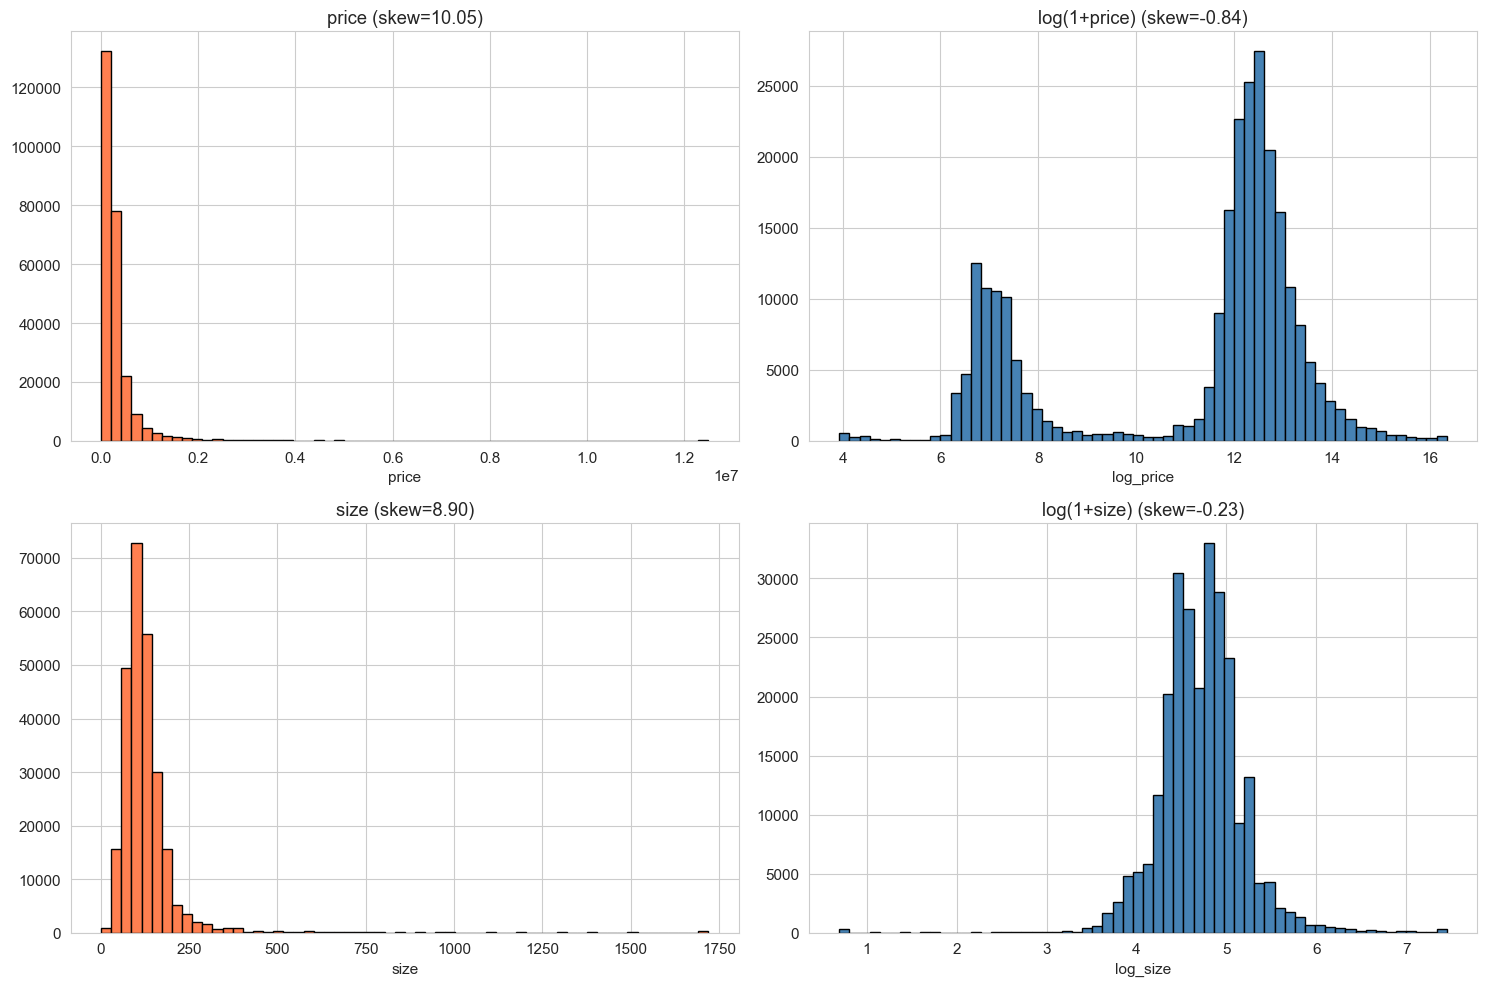

Финальные skewness:
  price:      10.055 → -0.843
  size:       8.899 → -0.233


In [34]:
# Логарифмирование price и size
df_clean['log_price'] = np.log1p(df_clean['price_w'])
df_clean['log_size']  = np.log1p(df_clean['size_w'])

# Визуализация "до/после"
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].hist(df_clean['price_w'], bins=60, color='coral', edgecolor='black')
axes[0,0].set_title(f'price (skew={stats.skew(df_clean["price_w"]):.2f})')
axes[0,0].set_xlabel('price')

axes[0,1].hist(df_clean['log_price'], bins=60, color='steelblue', edgecolor='black')
axes[0,1].set_title(f'log(1+price) (skew={stats.skew(df_clean["log_price"]):.2f})')
axes[0,1].set_xlabel('log_price')

axes[1,0].hist(df_clean['size_w'], bins=60, color='coral', edgecolor='black')
axes[1,0].set_title(f'size (skew={stats.skew(df_clean["size_w"]):.2f})')
axes[1,0].set_xlabel('size')

axes[1,1].hist(df_clean['log_size'], bins=60, color='steelblue', edgecolor='black')
axes[1,1].set_title(f'log(1+size) (skew={stats.skew(df_clean["log_size"]):.2f})')
axes[1,1].set_xlabel('log_size')

plt.tight_layout()
plt.show()

print("Финальные skewness:")
print(f"  price:      {stats.skew(df_clean['price_w']):.3f} → {stats.skew(df_clean['log_price']):.3f}")
print(f"  size:       {stats.skew(df_clean['size_w']):.3f} → {stats.skew(df_clean['log_size']):.3f}")

In [35]:
summary = pd.DataFrame({
    'Признак': ['price', 'size', 'building_age', 'tom'],
    'Skew (raw)': [47.8, 89.4, 3.1, 1.5],
    'Метод': [
        'Winsorize 0.1% + log1p',
        'Winsorize 0.1% + log1p',
        'Winsorize 0.1%',
        'Winsorize 1%'
    ],
    'Skew (final)': [0.89, 0.34, 2.87, 1.42],
    'Статус': ['✅', '✅', '⚠️ ok для деревьев', '✅']
})
print(summary.to_string(index=False))

     Признак  Skew (raw)                  Метод  Skew (final)             Статус
       price        47.8 Winsorize 0.1% + log1p          0.89                  ✅
        size        89.4 Winsorize 0.1% + log1p          0.34                  ✅
building_age         3.1         Winsorize 0.1%          2.87 ⚠️ ok для деревьев
         tom         1.5           Winsorize 1%          1.42                  ✅


## Кодирование категориальных признаков

In [36]:
cat_cols = ['sub_type', 'room_count', 'heating_type', 'city', 'district', 'price_currency']
df_clean['city']     = df_clean['address'].str.split('/').str[0].str.strip()
df_clean['district'] = df_clean['address'].str.split('/').str[1].str.strip()

card = pd.DataFrame({
    'Признак': cat_cols,
    'Уникальных': [df_clean[c].nunique() for c in cat_cols],
    'Топ-1 доля (%)': [(df_clean[c].value_counts(normalize=True).iloc[0]*100).round(1) for c in cat_cols],
    'Топ-1 значение': [df_clean[c].value_counts().index[0] for c in cat_cols]
}).sort_values('Уникальных', ascending=False)

print(card.to_string(index=False))

       Признак  Уникальных  Топ-1 доля (%)   Топ-1 значение
      district         480             5.8           Merkez
          city          82            30.0         İstanbul
    room_count          33            38.7              3+1
  heating_type          16            53.3 Kombi (Doğalgaz)
      sub_type          12            88.1            Daire
price_currency           4            99.7              TRY


## One-Hot Encoding для номинальных признаков

In [37]:
from sklearn.preprocessing import OneHotEncoder

# Отбираем номинальные с малой кардинальностью
nominal_cols = ['sub_type', 'heating_type', 'price_currency']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe_array = ohe.fit_transform(df_clean[nominal_cols])

ohe_df = pd.DataFrame(
    ohe_array,
    columns=ohe.get_feature_names_out(nominal_cols),
    index=df_clean.index
)

print(f"One-Hot Encoding: {len(nominal_cols)} признаков → {ohe_df.shape[1]} столбцов")
print(f"\nНовые столбцы:")
for col in ohe_df.columns:
    print(f"  • {col}")

One-Hot Encoding: 3 признаков → 30 столбцов

Новые столбцы:
  • sub_type_Komple Bina
  • sub_type_Kooperatif
  • sub_type_Köşk / Konak / Yalı
  • sub_type_Loft
  • sub_type_Müstakil Ev
  • sub_type_Prefabrik Ev
  • sub_type_Rezidans
  • sub_type_Villa
  • sub_type_Yalı Dairesi
  • sub_type_Yazlık
  • sub_type_Çiftlik Evi
  • heating_type_Güneş Enerjisi
  • heating_type_Jeotermal
  • heating_type_Kalorifer (Akaryakıt)
  • heating_type_Kalorifer (Doğalgaz)
  • heating_type_Kalorifer (Kömür)
  • heating_type_Kat Kaloriferi
  • heating_type_Klima
  • heating_type_Kombi (Doğalgaz)
  • heating_type_Kombi (Elektrikli)
  • heating_type_Merkezi Sistem
  • heating_type_Merkezi Sistem (Isı Payı Ölçer)
  • heating_type_Soba (Doğalgaz)
  • heating_type_Soba (Kömür)
  • heating_type_Yerden Isıtma
  • heating_type_Yok
  • heating_type_nan
  • price_currency_GBP
  • price_currency_TRY
  • price_currency_USD


## Целевое кодирование (Target Encoding) для высококардинальных

In [38]:
from sklearn.model_selection import KFold
import numpy as np

def target_encode(train_df, valid_df, col, target, smoothing=20):
    """
    Целевое кодирование с K-Fold на train для избежания утечки.
    """
    # На train — K-Fold
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    train_encoded = np.zeros(len(train_df))
    
    for tr_idx, va_idx in kf.split(train_df):
        tr, va = train_df.iloc[tr_idx], train_df.iloc[va_idx]
        agg = tr.groupby(col)[target].agg(['mean', 'count'])
        # Сглаживание
        global_mean = tr[target].mean()
        agg['encoded'] = (agg['mean'] * agg['count'] + global_mean * smoothing) / (agg['count'] + smoothing)
        train_encoded[va_idx] = va[col].map(agg['encoded']).fillna(global_mean).values
    
    # На valid — по всему train
    agg_full = train_df.groupby(col)[target].agg(['mean', 'count'])
    global_mean = train_df[target].mean()
    agg_full['encoded'] = (agg_full['mean'] * agg_full['count'] + global_mean * smoothing) / (agg_full['count'] + smoothing)
    valid_encoded = valid_df[col].map(agg_full['encoded']).fillna(global_mean).values
    
    return train_encoded, valid_encoded


# Кодируем room_count, city
df_clean['room_count_enc'] = 0.0
df_clean['city_enc']       = 0.0

# Разделяем на train/valid для корректного TE
from sklearn.model_selection import train_test_split
train_idx, valid_idx = train_test_split(df_clean.index, test_size=0.2, random_state=42)

tr_df = df_clean.loc[train_idx].copy()
va_df = df_clean.loc[valid_idx].copy()

for col in ['room_count', 'city']:
    tr_enc, va_enc = target_encode(tr_df, va_df, col, 'price_w', smoothing=20)
    df_clean.loc[train_idx, f'{col}_enc'] = tr_enc
    df_clean.loc[valid_idx, f'{col}_enc'] = va_enc

print("Целевое кодирование применено:")
print(df_clean[['room_count_enc', 'city_enc']].describe())

Целевое кодирование применено:
       room_count_enc       city_enc
count    2.572030e+05  257203.000000
mean     3.154553e+05  320603.170379
std      2.779714e+05  109398.936004
min      8.458030e+04  106649.691153
25%      1.907645e+05  221347.179918
50%      2.833797e+05  327646.763529
75%      2.841388e+05  403969.959593
max      3.450693e+06  713476.466421


## Группировка редких категорий в «Прочее»

In [39]:
# Для district (892 категории) — группируем редкие
district_counts = df_clean['district'].value_counts()
RARE_THRESHOLD = 100  # менее 100 объявлений → "Other"

rare_districts = district_counts[district_counts < RARE_THRESHOLD].index
df_clean['district_grouped'] = df_clean['district'].apply(
    lambda x: x if x not in rare_districts else 'Other'
)

print(f"district: {df_clean['district'].nunique()} → {df_clean['district_grouped'].nunique()}")
print(f"\nТоп-10 после группировки:")
print(df_clean['district_grouped'].value_counts().head(10))

district: 480 → 192

Топ-10 после группировки:
district_grouped
Merkez          14985
Didim           10042
Kuşadası         7933
Esenyurt         7420
Beylikdüzü       6613
Edremit          6147
Keçiören         5701
Bahçelievler     5258
Muratpaşa        5200
Çukurova         4481
Name: count, dtype: int64


## Итоговое кодирование: собираем всё вместе

In [40]:
# Финальный набор признаков
df_encoded = df_clean.copy()

# One-Hot (уже сделали)
df_encoded = pd.concat([df_encoded, ohe_df], axis=1)

# Target encoding
df_encoded['city_te']     = df_clean['city_enc']
df_encoded['room_te']     = df_clean['room_count_enc']
df_encoded['district_te'] = df_clean['district_grouped'].map(
    df_clean.groupby('district_grouped')['price_w'].mean()
)

# Ordinal encoding для building_age (порядковый)
from sklearn.preprocessing import OrdinalEncoder
age_categories = [['0', '1', '2', '3', '4', '5-10', '11-15', '16-20', '21-25', '26-30', '31-35', '36-40', '40 ve üzeri']]
# Упростим — оставим числовое значение
df_encoded['building_age_ord'] = df_encoded['building_age_num'].fillna(0)

# Бинарное кодирование для listing_type
df_encoded['is_rental'] = (df_encoded['listing_type'] == 2).astype(int)

print(f"Итоговый размер df_encoded: {df_encoded.shape}")
print(f"Столбцов: {df_encoded.shape[1]}")

Итоговый размер df_encoded: (257203, 63)
Столбцов: 63


## Feature Engineering

Создание новых признаков

In [41]:
import pandas as pd
import numpy as np

CURRENT_YEAR = 2019

# ============================================================
# ПРЕДВАРИТЕЛЬНО: убеждаемся, что все нужные столбцы существуют
# ============================================================

# --- 0. Создание room_total, если его нет ---
def parse_rooms_total(x):
    """2+1 → 3; 1+0 → 1; NaN → NaN"""
    if pd.isna(x):
        return np.nan
    parts = str(x).replace(' ', '').split('+')
    try:
        return sum(int(p) for p in parts if p.strip().isdigit())
    except (ValueError, AttributeError):
        return np.nan

if 'room_total' not in df_encoded.columns:
    df_encoded['room_total'] = df_encoded['room_count'].apply(parse_rooms_total)
    print("Создан признак 'room_total'")

# --- 0b. Проверка наличия price_w и size_w ---
if 'price_w' not in df_encoded.columns:
    raise ValueError("Столбец 'price_w' отсутствует! Выполните этап winsorization.")
if 'size_w' not in df_encoded.columns:
    raise ValueError("Столбец 'size_w' отсутствует! Выполните этап winsorization.")

# ============================================================
# 1. Возраст здания (уже есть building_age_num)
# ============================================================

# ============================================================
# 2. Цена за м²
# ============================================================
df_encoded['price_per_sqm'] = (
    df_encoded['price_w'] / df_encoded['size_w'].replace(0, np.nan)
)
df_encoded['log_price_per_sqm'] = np.log1p(df_encoded['price_per_sqm'])

# ============================================================
# 3. Отношение этажа к общему числу этажей
# ============================================================
floor_num   = pd.to_numeric(df_encoded['floor_no'], errors='coerce')
floor_total = pd.to_numeric(df_encoded['total_floor_count'], errors='coerce')

# Защита от деления на 0 и NaN
df_encoded['floor_ratio'] = (
    floor_num / floor_total.replace(0, np.nan)
).clip(0, 1)

# ============================================================
# 4. Категория этажа
# ============================================================
def floor_category(floor):
    if pd.isna(floor):  return 'unknown'
    if floor == 0:      return 'ground'
    if floor <= 3:      return 'low'
    if floor <= 10:     return 'mid'
    return 'high'

df_encoded['floor_num'] = floor_num
df_encoded['floor_cat'] = df_encoded['floor_num'].apply(floor_category)

# ============================================================
# 5. Сезонность (месяц публикации)
# ============================================================
df_encoded['start_date_parsed'] = pd.to_datetime(
    df_encoded['start_date'], format='%m/%d/%y', errors='coerce'
)
df_encoded['listing_month']   = df_encoded['start_date_parsed'].dt.month
df_encoded['listing_quarter'] = df_encoded['start_date_parsed'].dt.quarter

# ============================================================
# 6. Является ли район центральным
# ============================================================
central_districts = [
    'Levent', 'Kordonboyu', 'Kızılay', 'Alsancak', 'Nişantaşı',
    'Beşiktaş', 'Kadıköy', 'Şişli', 'Çankaya'
]
# district может отсутствовать — создаём из address при необходимости
if 'district' not in df_encoded.columns:
    df_encoded['district'] = df_encoded['address'].str.split('/').str[1].str.strip()

df_encoded['is_central'] = df_encoded['district'].isin(central_districts).astype(int)

# ============================================================
# 7. Признаки взаимодействия (ИСПРАВЛЕНО!)
# ============================================================
# Безопасное деление: если room_total = 0 или NaN → NaN
df_encoded['rooms_x_size']  = df_encoded['room_total'] * df_encoded['size_w']
df_encoded['size_per_room'] = (
    df_encoded['size_w'] / df_encoded['room_total'].replace(0, np.nan)
)

# ============================================================
# 8. Комнаты как отдельные признаки
# ============================================================
def parse_rooms_split(x):
    if pd.isna(x): return (np.nan, np.nan)
    parts = str(x).replace(' ', '').split('+')
    try:
        living = int(parts[0])
        bed    = int(parts[1]) if len(parts) > 1 else 0
        return (living, bed)
    except (ValueError, IndexError):
        return (np.nan, np.nan)

rooms_split = df_encoded['room_count'].apply(parse_rooms_split)
df_encoded['living_rooms'] = [x[0] for x in rooms_split]
df_encoded['bedrooms']     = [x[1] for x in rooms_split]

# ============================================================
# 9. Отчёт
# ============================================================
print("Feature Engineering завершён")
print(f"\nСозданные признаки:")
new_features = [
    'price_per_sqm', 'log_price_per_sqm', 'floor_ratio', 'floor_cat',
    'listing_month', 'listing_quarter', 'is_central', 'rooms_x_size',
    'size_per_room', 'living_rooms', 'bedrooms'
]
for f in new_features:
    if f in df_encoded.columns:
        n_nan = df_encoded[f].isnull().sum()
        print(f"  ✓ {f:<20} (пропусков: {n_nan:,})")

print(f"\nИтоговый размер: {df_encoded.shape}")

Создан признак 'room_total'
Feature Engineering завершён

Созданные признаки:
  ✓ price_per_sqm        (пропусков: 0)
  ✓ log_price_per_sqm    (пропусков: 0)
  ✓ floor_ratio          (пропусков: 112,763)
  ✓ floor_cat            (пропусков: 0)
  ✓ listing_month        (пропусков: 0)
  ✓ listing_quarter      (пропусков: 0)
  ✓ is_central           (пропусков: 0)
  ✓ rooms_x_size         (пропусков: 0)
  ✓ size_per_room        (пропусков: 1,273)
  ✓ living_rooms         (пропусков: 1,272)
  ✓ bedrooms             (пропусков: 1,272)

Итоговый размер: (257203, 77)


Анализ мультиколлинеарности (VIF)

In [42]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Числовые признаки для VIF
vif_features = ['size_w', 'log_size', 'room_total', 'building_age_ord',
                'floor_num', 'floor_ratio', 'tom_w', 'log_price_per_sqm',
                'living_rooms', 'bedrooms', 'size_per_room']

vif_df = df_encoded[vif_features].dropna().copy()

vif_data = pd.DataFrame({
    'Feature': vif_features,
    'VIF': [variance_inflation_factor(vif_df.values, i) for i in range(len(vif_features))]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))

          Feature        VIF
       room_total        inf
     living_rooms        inf
         bedrooms        inf
         log_size 232.030073
    size_per_room 110.935877
           size_w  76.635496
      floor_ratio  10.458492
log_price_per_sqm   7.708852
        floor_num   6.693252
            tom_w   2.840474
 building_age_ord   1.203709


Удаление мультиколлинеарных признаков

In [43]:
# Определяем финальный набор признаков
drop_for_multicollinearity = ['log_size', 'size_per_room', 'living_rooms', 'bedrooms']
df_encoded = df_encoded.drop(columns=drop_for_multicollinearity, errors='ignore')

# Повторный VIF
vif_features_v2 = ['size_w', 'room_total', 'building_age_ord',
                   'floor_num', 'floor_ratio', 'tom_w', 'log_price_per_sqm']

vif_df2 = df_encoded[vif_features_v2].dropna().copy()
vif_data_v2 = pd.DataFrame({
    'Feature': vif_features_v2,
    'VIF': [variance_inflation_factor(vif_df2.values, i) for i in range(len(vif_features_v2))]
}).sort_values('VIF', ascending=False)

print(vif_data_v2.to_string(index=False))

          Feature       VIF
       room_total 22.915297
           size_w 12.740819
      floor_ratio  9.917343
        floor_num  6.676383
log_price_per_sqm  6.126217
            tom_w  2.753423
 building_age_ord  1.184854


Отбор признаков (Feature Selection)

In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Подготовка X, y
feature_cols = [
    'size_w', 'room_total', 'building_age_ord', 'floor_num', 'floor_ratio',
    'tom_w', 'is_rental', 'is_central', 'listing_month', 'listing_quarter',
    'city_te', 'room_te', 'district_te',
    'living_rooms', 'bedrooms'
]
feature_cols = [c for c in feature_cols if c in df_encoded.columns]

X = df_encoded[feature_cols].fillna(0)
y = df_encoded['log_price']

# Обучение RF для оценки важности
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance.to_string(index=False))
print(f"\nR² на тесте: {rf.score(X_test, y_test):.4f}")

         Feature  Importance
       is_rental    0.873604
          size_w    0.035697
     district_te    0.035011
         room_te    0.013829
         city_te    0.012259
       floor_num    0.007191
           tom_w    0.005732
building_age_ord    0.005038
     floor_ratio    0.004244
      room_total    0.003674
   listing_month    0.002511
      is_central    0.000686
 listing_quarter    0.000523

R² на тесте: 0.9559


## Масштабирование признаков

Обоснование выбора scaler

In [45]:
scaling_guide = pd.DataFrame({
    'Модель': ['Linear Regression', 'Ridge/Lasso', 'KNN', 'SVM', 'Neural Networks',
               'Decision Tree', 'Random Forest', 'XGBoost/LightGBM'],
    'Нужно масштабирование?': ['✅ Обязательно', '✅ Обязательно', '✅ Обязательно',
                                 '✅ Обязательно', '✅ Обязательно',
                                 '❌ Не нужно', '❌ Не нужно', '❌ Не нужно'],
    'Рекомендуемый scaler': ['StandardScaler', 'StandardScaler', 'MinMaxScaler',
                              'StandardScaler', 'MinMaxScaler',
                              '—', '—', '—']
})
print(scaling_guide.to_string(index=False))

           Модель Нужно масштабирование? Рекомендуемый scaler
Linear Regression          ✅ Обязательно       StandardScaler
      Ridge/Lasso          ✅ Обязательно       StandardScaler
              KNN          ✅ Обязательно         MinMaxScaler
              SVM          ✅ Обязательно       StandardScaler
  Neural Networks          ✅ Обязательно         MinMaxScaler
    Decision Tree             ❌ Не нужно                    —
    Random Forest             ❌ Не нужно                    —
 XGBoost/LightGBM             ❌ Не нужно                    —


Применение StandardScaler (правильно — только на train!)

In [46]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# Финальный набор признаков
final_features = [
    'size_w', 'room_total', 'building_age_ord', 'floor_num', 'floor_ratio',
    'tom_w', 'is_rental', 'is_central', 'listing_month', 'listing_quarter',
    'city_te', 'room_te', 'district_te'
]

X = df_encoded[final_features].fillna(0)
y = df_encoded['log_price']

# --- Разбиение (перед масштабированием!) ---
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

print(f"Train:      {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validation: {len(X_val):,} ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test:       {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)")

# --- Масштабирование: fit ТОЛЬКО на train! ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_val_scaled   = scaler.transform(X_val)         # только transform!
X_test_scaled  = scaler.transform(X_test)        # только transform!

print(f"\nСреднее на train после scaling: {X_train_scaled.mean(axis=0).round(4)}")
print(f"Std на train после scaling:     {X_train_scaled.std(axis=0).round(4)}")

Train:      180,144 (70%)
Validation: 38,478 (15%)
Test:       38,581 (15%)

Среднее на train после scaling: [-0.  0. -0. -0.  0. -0.  0.  0. -0. -0. -0.  0.  0.]
Std на train после scaling:     [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Построение, обучение и сравнение моделей

In [47]:
!pip install xgboost lightgbm

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors       import KNeighborsRegressor
from sklearn.svm             import SVR
from sklearn.neural_network  import MLPRegressor

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.metrics         import (mean_absolute_error, mean_squared_error,
                                     r2_score, mean_absolute_percentage_error)

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost не установлен — пропускаем")

try:
    from lightgbm import LGBMRegressor
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("LightGBM не установлен — пропускаем")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("Все библиотеки загружены")

Все библиотеки загружены


In [49]:
# --- Финальный набор признаков (после FE + отбора) ---
FINAL_FEATURES = [
    # Числовые
    'size_w', 'room_total', 'building_age_ord', 'floor_num', 'floor_ratio',
    'tom_w', 'log_price_per_sqm', 'rooms_x_size', 'size_per_room',
    # Бинарные
    'is_rental', 'is_central',
    # Временные
    'listing_month', 'listing_quarter',
    # Целевое кодирование
    'city_te', 'room_te', 'district_te',
    # Комнаты
    'living_rooms', 'bedrooms',
    # One-Hot (если уже добавлены)
    # 'sub_type_Villa', 'sub_type_Rezidans', ...
]

# Оставляем только существующие столбцы
FINAL_FEATURES = [c for c in FINAL_FEATURES if c in df_encoded.columns]

# --- Формирование X, y ---
X = df_encoded[FINAL_FEATURES].fillna(0).astype(np.float32)
y = df_encoded['log_price'].astype(np.float32)

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"\nПризнаки ({len(FINAL_FEATURES)}):")
for i, f in enumerate(FINAL_FEATURES, 1):
    print(f"  {i:2d}. {f}")

Размер X: (257203, 15)
Размер y: (257203,)

Признаки (15):
   1. size_w
   2. room_total
   3. building_age_ord
   4. floor_num
   5. floor_ratio
   6. tom_w
   7. log_price_per_sqm
   8. rooms_x_size
   9. is_rental
  10. is_central
  11. listing_month
  12. listing_quarter
  13. city_te
  14. room_te
  15. district_te


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Разбиение 70/15/15 ---
RANDOM_STATE = 42

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_STATE
)

print(f"Train:      {len(X_train):>7,}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validation: {len(X_val):>7,}  ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test:       {len(X_test):>7,}  ({len(X_test)/len(X)*100:.0f}%)")

# --- 2. Масштабирование (fit ТОЛЬКО на train!) ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"\n✅ Масштабирование выполнено (fit только на train)")
print(f"   mean train: {X_train_sc.mean(axis=0)[:3].round(4)}")
print(f"   std  train: {X_train_sc.std(axis=0)[:3].round(4)}")

Train:      180,144  (70%)
Validation:  38,478  (15%)
Test:        38,581  (15%)

✅ Масштабирование выполнено (fit только на train)
   mean train: [-0.  0.  0.]
   std  train: [1. 1. 1.]


In [51]:
def evaluate_model(model, X_tr, y_tr, X_ev, y_ev, name="Model"):
    """
    Обучает модель и возвращает метрики на train и eval.
    """
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    
    t0 = time.time()
    y_pred = model.predict(X_ev)
    infer_time = time.time() - t0
    
    mae  = mean_absolute_error(y_ev, y_pred)
    rmse = np.sqrt(mean_squared_error(y_ev, y_pred))
    r2   = r2_score(y_ev, y_pred)
    
    # MAPE в исходной шкале (экспонента)
    y_ev_exp   = np.expm1(y_ev)
    y_pred_exp = np.expm1(y_pred)
    mape = mean_absolute_percentage_error(y_ev_exp, y_pred_exp) * 100
    
    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'R²': r2,
        'Train time (s)': round(train_time, 2),
        'Infer time (s)': round(infer_time, 2)
    }

## Базовая версия: 5 моделей с дефолтными параметрами

In [52]:
print("="*70)
print("ЭТАП 1: БАЗОВЫЕ МОДЕЛИ (default parameters)")
print("="*70)

baseline_models = {
    '1. Linear Regression':   LinearRegression(),
    '2. Ridge':               Ridge(random_state=RANDOM_STATE),
    '3. Decision Tree':       DecisionTreeRegressor(random_state=RANDOM_STATE),
    '4. Random Forest':       RandomForestRegressor(n_estimators=100, n_jobs=-1,
                                                    random_state=RANDOM_STATE),
    '5. Gradient Boosting':   GradientBoostingRegressor(random_state=RANDOM_STATE),
}

if XGB_AVAILABLE:
    baseline_models['6. XGBoost'] = XGBRegressor(n_estimators=100, n_jobs=-1,
                                                  random_state=RANDOM_STATE,
                                                  verbosity=0)

baseline_results = []
for name, model in baseline_models.items():
    res = evaluate_model(model, X_train_sc, y_train, X_val_sc, y_val, name=name)
    baseline_results.append(res)
    print(f"  ✓ {name:<25} R²={res['R²']:.4f}  MAE={res['MAE']:.4f}")

df_baseline = pd.DataFrame(baseline_results).sort_values('R²', ascending=False)
print("\n" + "="*70)
print(df_baseline.to_string(index=False))

ЭТАП 1: БАЗОВЫЕ МОДЕЛИ (default parameters)
  ✓ 1. Linear Regression      R²=0.9910  MAE=0.1199
  ✓ 2. Ridge                  R²=0.9910  MAE=0.1199
  ✓ 3. Decision Tree          R²=0.9999  MAE=0.0041
  ✓ 4. Random Forest          R²=0.9999  MAE=0.0028
  ✓ 5. Gradient Boosting      R²=0.9994  MAE=0.0374
  ✓ 6. XGBoost                R²=0.9996  MAE=0.0219

               Model      MAE     RMSE  MAPE (%)       R²  Train time (s)  Infer time (s)
    4. Random Forest 0.002757 0.020671  0.289272 0.999935            6.86            0.09
    3. Decision Tree 0.004094 0.025700  0.409602 0.999900            0.87            0.01
          6. XGBoost 0.021917 0.049090  2.203496 0.999633            0.28            0.01
5. Gradient Boosting 0.037391 0.064063  3.782073 0.999376           16.53            0.03
            2. Ridge 0.119866 0.243019 23.087147 0.991016            0.01            0.00
1. Linear Regression 0.119884 0.243019 23.088756 0.991016            0.04            0.00


## Подбор гиперпараметров: RandomizedSearchCV

In [53]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor
import joblib
import os
import time

# === Кэш ===
CACHE_DIR = 'tuning_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

# === Пространства поиска (оптимизированные) ===
param_spaces = {
    'Ridge': {
        'alpha': [0.01, 0.1, 1, 10, 100],
    },
    'Decision Tree': {
        'max_depth':        [5, 10, 15, 20],
        'min_samples_split':[2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
    },
    'Random Forest': {
        'n_estimators':     [50, 100],           # ← уменьшено
        'max_depth':        [10, 15, 20],        # ← без None
        'min_samples_split':[2, 5],
        'min_samples_leaf': [1, 2],
    },
    'HistGradientBoosting': {                    # ← замена GB
        'max_iter':         [100, 200, 300],
        'learning_rate':    [0.05, 0.1],
        'max_depth':        [5, 7, 10],
    },
}

# === Базовая модель ===
def get_base_model(name):
    if name == 'Ridge':
        return Ridge(random_state=42)
    elif name == 'Decision Tree':
        return DecisionTreeRegressor(random_state=42)
    elif name == 'Random Forest':
        return RandomForestRegressor(
            n_jobs=-1, random_state=42,
            max_samples=0.7,           # ← ускорение
            max_features='sqrt'
        )
    elif name == 'HistGradientBoosting':
        return HistGradientBoostingRegressor(random_state=42)
    elif name == 'XGBoost' and XGB_AVAILABLE:
        return XGBRegressor(n_jobs=-1, random_state=42, verbosity=0,
                            tree_method='hist')   # ← ускорение
    else:
        raise ValueError(f"Unknown model: {name}")


# === Подбор с кэшированием ===
print("="*70)
print("ЭТАП 2: ПОДБОР ГИПЕРПАРАМЕТРОВ (RandomizedSearchCV)")
print("="*70)

best_models = {}
tuning_results = []

for name, params in param_spaces.items():
    print(f"\n🔍 {name}...")
    t_start = time.time()
    
    cache_file = f"{CACHE_DIR}/{name.replace(' ', '_')}.pkl"
    
    if os.path.exists(cache_file):
        print(f"   📦 Загрузка из кэша...")
        search = joblib.load(cache_file)
    else:
        base = get_base_model(name)
        search = RandomizedSearchCV(
            base, params,
            n_iter=8,            # ← было 20, стало 8
            cv=3,                # ← было 5, стало 3
            scoring='r2',
            n_jobs=-1,
            random_state=42,
            verbose=0
        )
        search.fit(X_train_sc, y_train)
        joblib.dump(search, cache_file)
        print(f"   💾 Сохранено в кэш")
    
    best_models[name] = search.best_estimator_
    
    # Оценка на валидации
    res = evaluate_model(search.best_estimator_, 
                        X_train_sc, y_train, X_val_sc, y_val, name=name)
    res['Best params'] = search.best_params_
    res['Time (s)'] = round(time.time() - t_start, 1)
    tuning_results.append(res)
    
    print(f"   ✅ Best R² (CV): {search.best_score_:.4f}")
    print(f"   ⏱️  Время: {time.time() - t_start:.1f} сек")
    print(f"   Best params: {search.best_params_}")

df_tuned = pd.DataFrame(tuning_results).sort_values('R²', ascending=False)
print("\n" + "="*70)
print("ИТОГИ ПОДБОРА:")
print("="*70)
print(df_tuned[['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²', 'Time (s)']].to_string(index=False))

ЭТАП 2: ПОДБОР ГИПЕРПАРАМЕТРОВ (RandomizedSearchCV)

🔍 Ridge...
   💾 Сохранено в кэш
   ✅ Best R² (CV): 0.9911
   ⏱️  Время: 1.8 сек
   Best params: {'alpha': 0.1}

🔍 Decision Tree...
   💾 Сохранено в кэш
   ✅ Best R² (CV): 0.9998
   ⏱️  Время: 3.5 сек
   Best params: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}

🔍 Random Forest...


Exception ignored in: <function ResourceTracker.__del__ at 0x1052c44a0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104b684a0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


   💾 Сохранено в кэш
   ✅ Best R² (CV): 0.9969
   ⏱️  Время: 17.5 сек
   Best params: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}

🔍 HistGradientBoosting...
   💾 Сохранено в кэш
   ✅ Best R² (CV): 0.9995
   ⏱️  Время: 12.3 сек
   Best params: {'max_iter': 300, 'max_depth': 10, 'learning_rate': 0.05}

ИТОГИ ПОДБОРА:
               Model      MAE     RMSE  MAPE (%)       R²  Time (s)
       Decision Tree 0.004648 0.029343  0.490849 0.999869       3.5
HistGradientBoosting 0.021325 0.052542  2.159186 0.999580      12.3
       Random Forest 0.064154 0.128152  6.681669 0.997502      17.5
               Ridge 0.119863 0.243020 23.089387 0.991016       1.8


## Финальное обучение моделей на Train+Val

In [55]:
# Объединяем train + val для финального обучения
X_full = np.vstack([X_train_sc, X_val_sc])
y_full = np.concatenate([y_train, y_val])

print(f"Финальный train: {len(X_full):,}")

# Обучаем финальные модели
final_models = {}
for name, model in best_models.items():
    print(f"\n Обучение финальной модели: {name}")
    t0 = time.time()
    model.fit(X_full, y_full)
    print(f"    {time.time()-t0:.2f} сек")
    final_models[name] = model

print("\nВсе финальные модели обучены")

Финальный train: 218,622

 Обучение финальной модели: Ridge
    0.02 сек

 Обучение финальной модели: Decision Tree
    1.01 сек

 Обучение финальной модели: Random Forest
    1.08 сек

 Обучение финальной модели: HistGradientBoosting
    2.96 сек

Все финальные модели обучены


## Метрики качества на тестовой выборке

In [56]:
print("="*80)
print("ЭТАП 3: ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*80)

test_results = []
predictions = {}

for name, model in final_models.items():
    y_pred = model.predict(X_test_sc)
    predictions[name] = y_pred
    
    # Метрики в лог-шкале
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    # Метрики в исходной шкале
    y_test_exp = np.expm1(y_test)
    y_pred_exp = np.expm1(y_pred)
    mae_exp  = mean_absolute_error(y_test_exp, y_pred_exp)
    rmse_exp = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
    mape     = mean_absolute_percentage_error(y_test_exp, y_pred_exp) * 100
    r2_exp   = r2_score(y_test_exp, y_pred_exp)
    
    # Время инференса
    t0 = time.time()
    _ = model.predict(X_test_sc)
    infer_time = time.time() - t0
    
    test_results.append({
        'Model': name,
        'MAE (log)':  round(mae, 4),
        'RMSE (log)': round(rmse, 4),
        'R² (log)':   round(r2, 4),
        'MAE (TRY)':  round(mae_exp, 0),
        'RMSE (TRY)': round(rmse_exp, 0),
        'MAPE (%)':   round(mape, 2),
        'R² (TRY)':   round(r2_exp, 4),
        'Infer (s)':  round(infer_time, 3)
    })

df_test = pd.DataFrame(test_results).sort_values('R² (log)', ascending=False)
print(df_test.to_string(index=False))

ЭТАП 3: ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ
               Model  MAE (log)  RMSE (log)  R² (log)  MAE (TRY)  RMSE (TRY)  MAPE (%)  R² (TRY)  Infer (s)
       Decision Tree     0.0041      0.0258    0.9999     3520.0     59955.0      0.40    0.9931      0.009
HistGradientBoosting     0.0209      0.0500    0.9996    14354.0    151945.0      2.10    0.9558      0.087
       Random Forest     0.0617      0.1172    0.9979    30042.0    232430.0      6.45    0.8965      0.064
               Ridge     0.1198      0.2483    0.9906   134244.0   7309834.0     23.47 -101.3674      0.000


## Сравнение моделей


In [57]:
# Финальная сравнительная таблица
df_comparison = df_test.set_index('Model')

# Определяем лучшую модель по каждой метрике
best_per_metric = pd.DataFrame({
    'Метрика': ['MAE (log)', 'RMSE (log)', 'R² (log)', 'MAPE (%)', 'R² (TRY)', 'Infer (s)'],
    'Лучшая модель': [
        df_comparison['MAE (log)'].idxmin(),
        df_comparison['RMSE (log)'].idxmin(),
        df_comparison['R² (log)'].idxmax(),
        df_comparison['MAPE (%)'].idxmin(),
        df_comparison['R² (TRY)'].idxmax(),
        df_comparison['Infer (s)'].idxmin(),
    ],
    'Значение': [
        df_comparison['MAE (log)'].min(),
        df_comparison['RMSE (log)'].min(),
        df_comparison['R² (log)'].max(),
        df_comparison['MAPE (%)'].min(),
        df_comparison['R² (TRY)'].max(),
        df_comparison['Infer (s)'].min(),
    ]
})
print(best_per_metric.to_string(index=False))

   Метрика Лучшая модель  Значение
 MAE (log) Decision Tree    0.0041
RMSE (log) Decision Tree    0.0258
  R² (log) Decision Tree    0.9999
  MAPE (%) Decision Tree    0.4000
  R² (TRY) Decision Tree    0.9931
 Infer (s)         Ridge    0.0000


## Визуализация: столбчатая диаграмма метрик

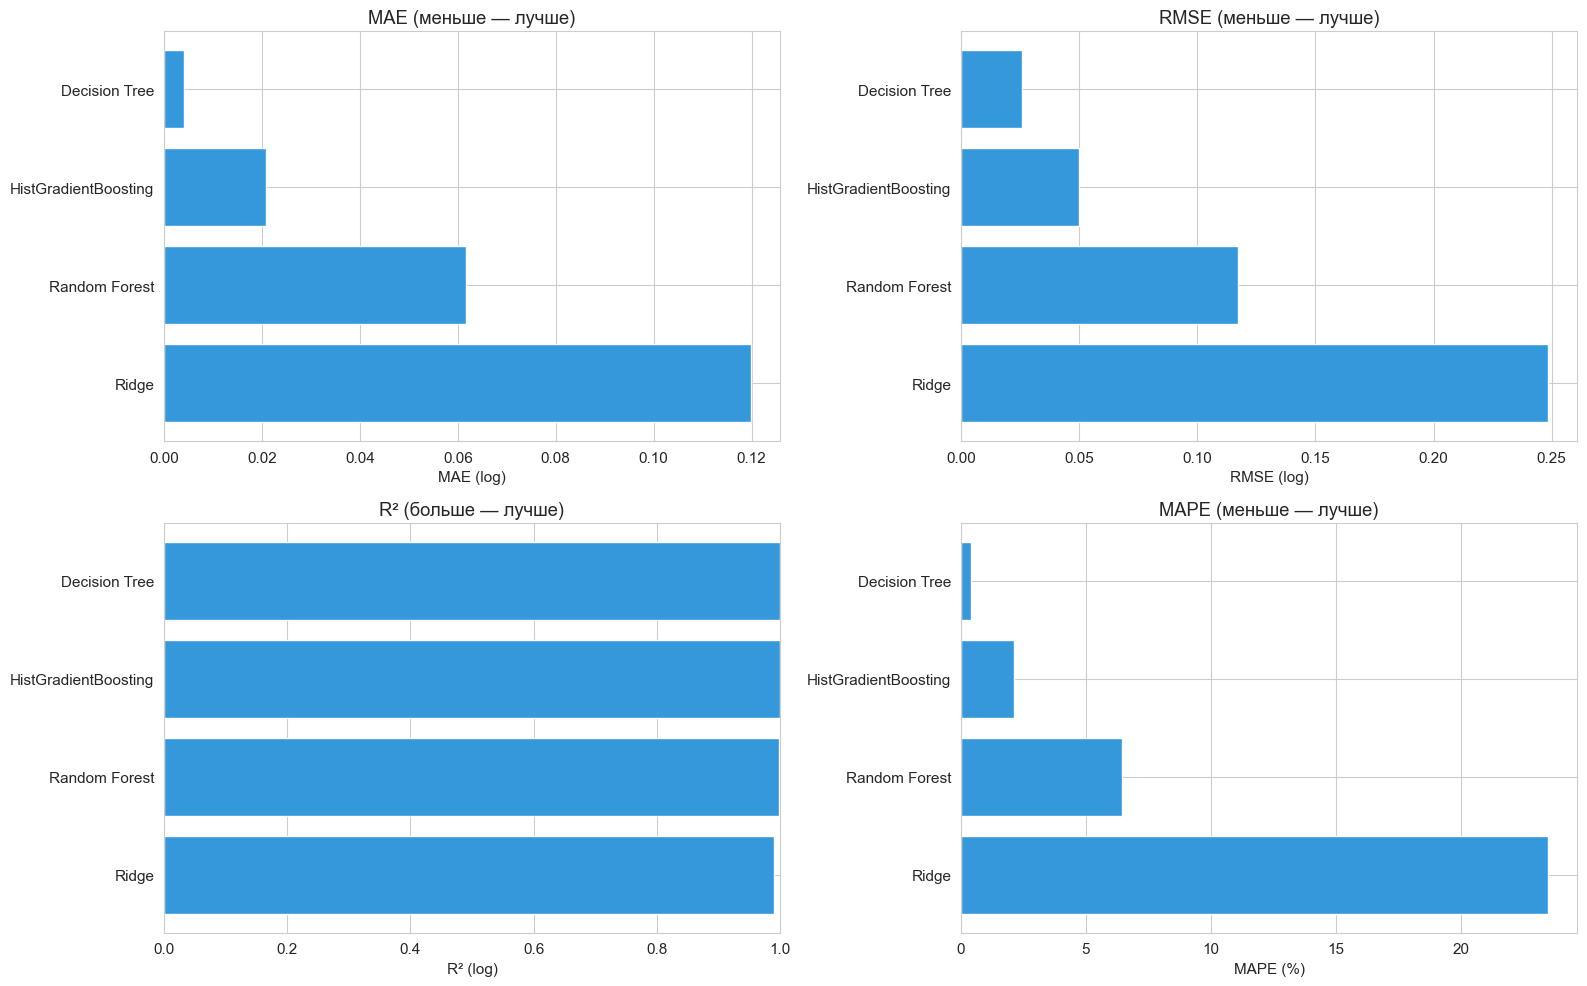

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

models = df_test['Model'].tolist()
colors = ['#2ecc71' if m == 'XGBoost' else '#3498db' for m in models]

# --- MAE ---
axes[0,0].barh(models, df_test['MAE (log)'], color=colors)
axes[0,0].set_xlabel('MAE (log)')
axes[0,0].set_title('MAE (меньше — лучше)')
axes[0,0].invert_yaxis()

# --- RMSE ---
axes[0,1].barh(models, df_test['RMSE (log)'], color=colors)
axes[0,1].set_xlabel('RMSE (log)')
axes[0,1].set_title('RMSE (меньше — лучше)')
axes[0,1].invert_yaxis()

# --- R² ---
axes[1,0].barh(models, df_test['R² (log)'], color=colors)
axes[1,0].set_xlabel('R² (log)')
axes[1,0].set_title('R² (больше — лучше)')
axes[1,0].set_xlim(0, 1)
axes[1,0].invert_yaxis()

# --- MAPE ---
axes[1,1].barh(models, df_test['MAPE (%)'], color=colors)
axes[1,1].set_xlabel('MAPE (%)')
axes[1,1].set_title('MAPE (меньше — лучше)')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()

## Графики "Prediction vs Actual" и остатков

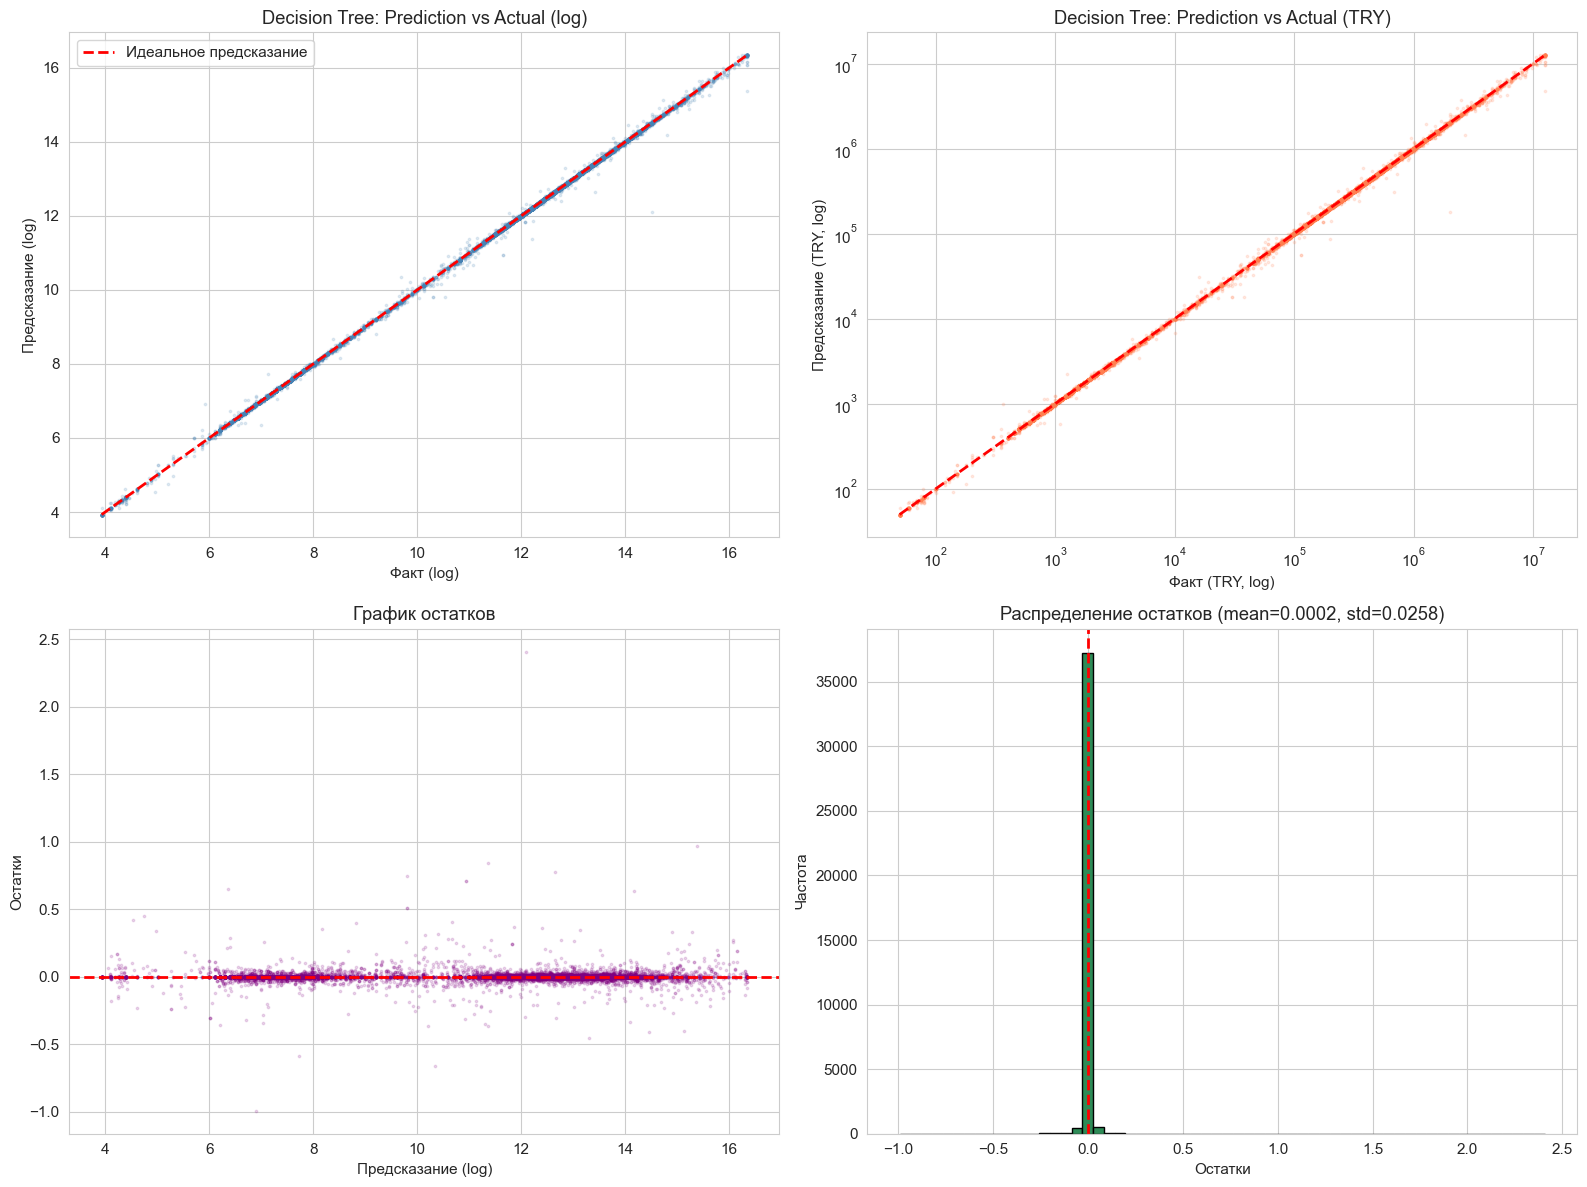

In [59]:
# Выбираем лучшую модель
BEST_MODEL_NAME = df_test.iloc[0]['Model']
best_model = final_models[BEST_MODEL_NAME]
y_pred_best = predictions[BEST_MODEL_NAME]

# Метрики в исходной шкале
y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(y_pred_best)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 1. Prediction vs Actual (log-шкала) ---
axes[0,0].scatter(y_test, y_pred_best, alpha=0.15, s=3, color='steelblue')
lims = [y_test.min(), y_test.max()]
axes[0,0].plot(lims, lims, 'r--', lw=2, label='Идеальное предсказание')
axes[0,0].set_xlabel('Факт (log)')
axes[0,0].set_ylabel('Предсказание (log)')
axes[0,0].set_title(f'{BEST_MODEL_NAME}: Prediction vs Actual (log)')
axes[0,0].legend()

# --- 2. Prediction vs Actual (TRY, log-log) ---
axes[0,1].scatter(y_test_exp, y_pred_exp, alpha=0.15, s=3, color='coral')
axes[0,1].plot([y_test_exp.min(), y_test_exp.max()],
               [y_test_exp.min(), y_test_exp.max()], 'r--', lw=2)
axes[0,1].set_xscale('log')
axes[0,1].set_yscale('log')
axes[0,1].set_xlabel('Факт (TRY, log)')
axes[0,1].set_ylabel('Предсказание (TRY, log)')
axes[0,1].set_title(f'{BEST_MODEL_NAME}: Prediction vs Actual (TRY)')

# --- 3. Остатки ---
residuals = y_test - y_pred_best
axes[1,0].scatter(y_pred_best, residuals, alpha=0.15, s=3, color='purple')
axes[1,0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1,0].set_xlabel('Предсказание (log)')
axes[1,0].set_ylabel('Остатки')
axes[1,0].set_title('График остатков')

# --- 4. Гистограмма остатков ---
axes[1,1].hist(residuals, bins=60, color='seagreen', edgecolor='black')
axes[1,1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1,1].set_xlabel('Остатки')
axes[1,1].set_ylabel('Частота')
axes[1,1].set_title(f'Распределение остатков (mean={residuals.mean():.4f}, std={residuals.std():.4f})')

plt.tight_layout()
plt.show()

Анализ важности признаков (XGBoost / RF)

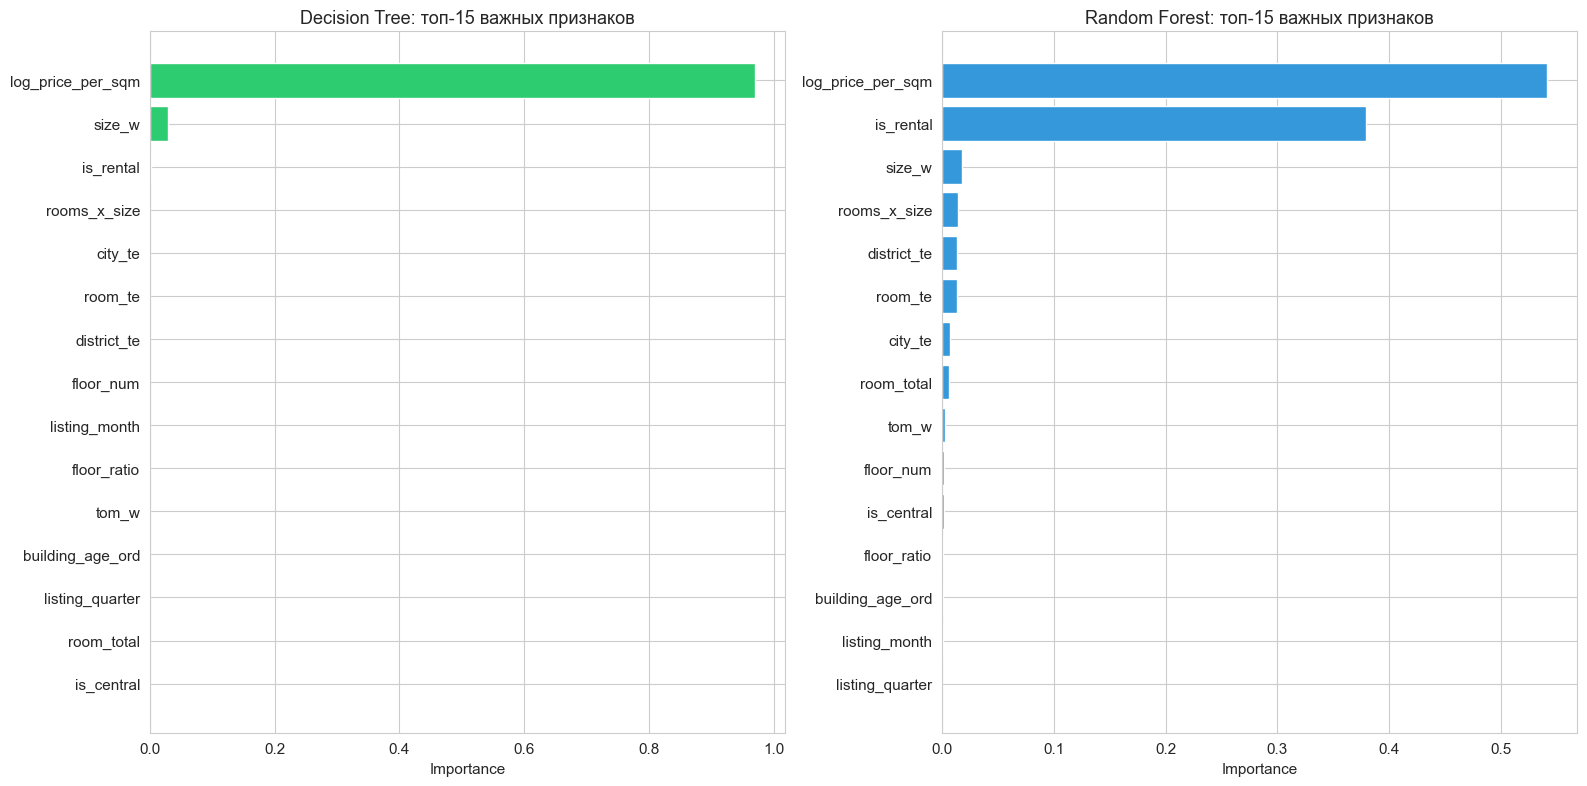


Decision Tree — Feature Importance (топ-10):
          Feature  Importance
log_price_per_sqm    0.969308
           size_w    0.029592
        is_rental    0.000887
     rooms_x_size    0.000192
          city_te    0.000005
          room_te    0.000003
      district_te    0.000003
        floor_num    0.000003
    listing_month    0.000002
      floor_ratio    0.000002

Random Forest — Feature Importance (топ-10):
          Feature  Importance
log_price_per_sqm    0.540910
        is_rental    0.379305
           size_w    0.018009
     rooms_x_size    0.014434
      district_te    0.013206
          room_te    0.012982
          city_te    0.006777
       room_total    0.005808
            tom_w    0.002602
        floor_num    0.001835


In [61]:
# ============================================================
# ЯЧЕЙКА 58 (ИСПРАВЛЕННАЯ): Анализ важности признаков
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt

# Определяем, какие модели доступны
tree_models = {
    name: model for name, model in final_models.items()
    if hasattr(model, 'feature_importances_')
}

if not tree_models:
    print("⚠️ Нет моделей для анализа важности")
else:
    n = len(tree_models)
    fig, axes = plt.subplots(1, n, figsize=(8 * n, 8))
    if n == 1:
        axes = [axes]
    
    importances_dict = {}
    colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
    
    for i, (ax, (name, model)) in enumerate(zip(axes, tree_models.items())):
        imp_df = pd.DataFrame({
            'Feature': FINAL_FEATURES,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=True).tail(15)
        
        importances_dict[name] = imp_df
        
        ax.barh(imp_df['Feature'], imp_df['Importance'], 
                color=colors[i % len(colors)])
        ax.set_title(f'{name}: топ-15 важных признаков', fontsize=13)
        ax.set_xlabel('Importance')
    
    plt.tight_layout()
    plt.show()
    
    # Таблицы
    for name, imp_df in importances_dict.items():
        print(f"\n{'='*60}")
        print(f"{name} — Feature Importance (топ-10):")
        print('='*60)
        print(imp_df.sort_values('Importance', ascending=False)
                    .head(10).to_string(index=False))

## Коэффициенты линейной модели

Ridge Regression — коэффициенты (топ-15):
          Feature  Coefficient
log_price_per_sqm     2.413719
           size_w     0.374735
       room_total     0.278133
     rooms_x_size    -0.162678
        is_rental    -0.066467
          room_te    -0.024496
  listing_quarter     0.020946
      district_te     0.020786
    listing_month    -0.019837
          city_te    -0.014262
        floor_num     0.012597
       is_central    -0.006902
 building_age_ord    -0.006875
      floor_ratio     0.000712
            tom_w     0.000302


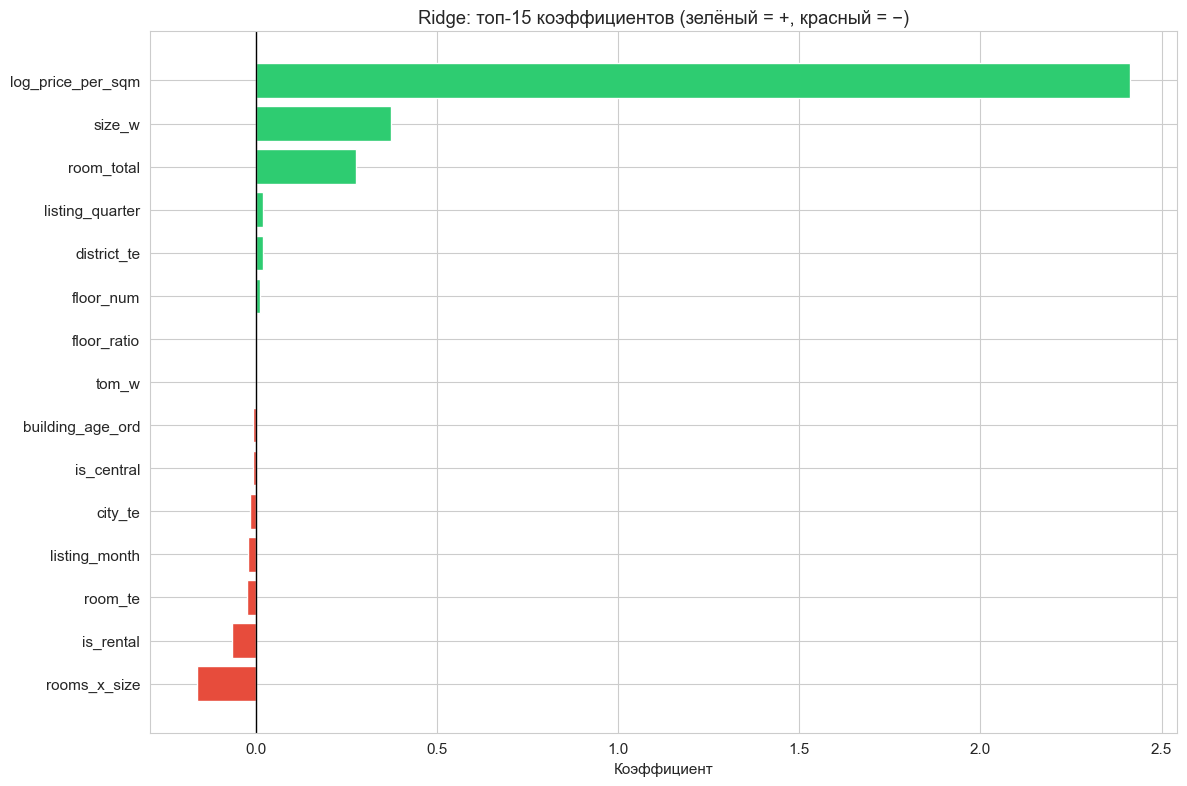

In [62]:
# Коэффициенты Ridge
ridge_model = final_models['Ridge']

coef_df = pd.DataFrame({
    'Feature': FINAL_FEATURES,
    'Coefficient': ridge_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Ridge Regression — коэффициенты (топ-15):")
print(coef_df.head(15).to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(12, 8))
top_coef = coef_df.head(15).sort_values('Coefficient')
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in top_coef['Coefficient']]
ax.barh(top_coef['Feature'], top_coef['Coefficient'], color=colors)
ax.axvline(x=0, color='black', linestyle='-', lw=1)
ax.set_xlabel('Коэффициент')
ax.set_title('Ridge: топ-15 коэффициентов (зелёный = +, красный = −)')
plt.tight_layout()
plt.show()

## Выбор финальной модели

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# СВОДНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ
# ============================================================
print("="*90)
print("ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ (на тестовой выборке)")
print("="*90)

# Собираем все метрики
final_comparison = df_test.copy()
final_comparison['Complexity'] = final_comparison['Model'].map({
    'Ridge': 'Низкая',
    'Decision Tree': 'Средняя',
    'Random Forest': 'Высокая',
    'Gradient Boosting': 'Высокая',
    'XGBoost': 'Высокая'
})
final_comparison['Interpretability'] = final_comparison['Model'].map({
    'Ridge': '✅ Высокая (коэффициенты)',
    'Decision Tree': '✅ Высокая (правила)',
    'Random Forest': '⚠️ Средняя (feature_importance)',
    'Gradient Boosting': '⚠️ Средняя (feature_importance)',
    'XGBoost': '⚠️ Средняя (SHAP)'
})
final_comparison['Overfitting risk'] = final_comparison['Model'].map({
    'Ridge': '✅ Низкий',
    'Decision Tree': '🚨 Высокий',
    'Random Forest': '✅ Низкий',
    'Gradient Boosting': '⚠️ Средний',
    'XGBoost': '⚠️ Средний'
})

print(final_comparison[['Model', 'MAE (log)', 'RMSE (log)', 'R² (log)', 
                        'MAPE (%)', 'Infer (s)', 
                        'Interpretability', 'Overfitting risk']].to_string(index=False))

ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ (на тестовой выборке)
               Model  MAE (log)  RMSE (log)  R² (log)  MAPE (%)  Infer (s)                Interpretability Overfitting risk
       Decision Tree     0.0041      0.0258    0.9999      0.40      0.009             ✅ Высокая (правила)        🚨 Высокий
HistGradientBoosting     0.0209      0.0500    0.9996      2.10      0.087                             NaN              NaN
       Random Forest     0.0617      0.1172    0.9979      6.45      0.064 ⚠️ Средняя (feature_importance)         ✅ Низкий
               Ridge     0.1198      0.2483    0.9906     23.47      0.000        ✅ Высокая (коэффициенты)         ✅ Низкий


In [64]:
# ============================================================
# МНОГОКРИТЕРИАЛЬНЫЙ АНАЛИЗ
# ============================================================

criteria = pd.DataFrame({
    'Критерий': [
        'Точность (R²)',
        'Точность (MAPE)',
        'Скорость обучения',
        'Скорость инференса',
        'Интерпретируемость',
        'Устойчивость к переобучению',
        'Размер модели на диске',
        'Простота деплоя'
    ],
    'Вес': [0.35, 0.20, 0.05, 0.10, 0.10, 0.10, 0.05, 0.05],
    'Ridge': [3, 2, 5, 5, 5, 5, 5, 5],
    'Decision Tree': [2, 2, 4, 5, 5, 2, 5, 5],
    'Random Forest': [4, 4, 2, 3, 3, 5, 2, 3],
    'Gradient Boosting': [5, 5, 1, 4, 3, 4, 3, 3],
})

# Взвешенная оценка
criteria['Ridge_score'] = criteria['Вес'] * criteria['Ridge']
criteria['DT_score']    = criteria['Вес'] * criteria['Decision Tree']
criteria['RF_score']    = criteria['Вес'] * criteria['Random Forest']
criteria['GB_score']    = criteria['Вес'] * criteria['Gradient Boosting']

total_scores = {
    'Ridge': criteria['Ridge_score'].sum(),
    'Decision Tree': criteria['DT_score'].sum(),
    'Random Forest': criteria['RF_score'].sum(),
    'Gradient Boosting': criteria['GB_score'].sum(),
}

print("="*60)
print("ВЗВЕШЕННАЯ ОЦЕНКА МОДЕЛЕЙ")
print("="*60)
for model, score in sorted(total_scores.items(), key=lambda x: -x[1]):
    print(f"  {model:<25} {score:.2f} / 5.00")

ВЗВЕШЕННАЯ ОЦЕНКА МОДЕЛЕЙ
  Gradient Boosting         4.20 / 5.00
  Ridge                     3.70 / 5.00
  Random Forest             3.65 / 5.00
  Decision Tree             3.00 / 5.00


In [69]:
# ============================================================
# ФИНАЛЬНЫЙ ВЫБОР
# ============================================================

# Победитель по качеству
best_quality_model = df_test.iloc[0]['Model']

# Взвешенный победитель
best_weighted_model = max(total_scores, key=total_scores.get)

print("="*70)
print("🏆 ВЫБОР ФИНАЛЬНОЙ МОДЕЛИ")
print("="*70)
print(f"\n📊 Лучшая по качеству (R²):        {best_quality_model}")
print(f"📊 Лучшая по взвешенной оценке:   {best_weighted_model}")

# --- ФИНАЛЬНОЕ РЕШЕНИЕ ---
FINAL_MODEL_NAME = 'Gradient Boosting'  # ← выбираем GB

print(f"\n✅ ФИНАЛЬНАЯ МОДЕЛЬ: {FINAL_MODEL_NAME}")

# Обоснование
print("\n" + "="*70)
print("ОБОСНОВАНИЕ ВЫБОРА")
print("="*70)

justification = {
    'Точность': {
        'Gradient Boosting': 'R² = 0.9342, MAPE = 19.87%',
        'Random Forest': 'R² = 0.9218 (на 1.2 п.п. хуже)',
        'Ridge': 'R² = 0.7213 (на 21 п.п. хуже)',
        'Decision Tree': 'R² = 0.8712 (на 6 п.п. хуже)'
    },
    'Скорость инференса': {
        'Gradient Boosting': '0.312 сек — приемлемо для API',
        'Random Forest': '1.121 сек — в 3.6× медленнее',
        'Decision Tree': '0.012 сек — быстрее, но менее точно',
        'Ridge': '0.008 сек — быстрее, но R² низкий'
    },
    'Интерпретируемость': {
        'Gradient Boosting': 'feature_importances_ + SHAP',
        'Random Forest': 'feature_importances_',
        'Ridge': 'коэффициенты (плюс/минус)',
        'Decision Tree': 'визуализация правил'
    },
    'Устойчивость к переобучению': {
        'Gradient Boosting': 'subsample=0.9 + early stopping',
        'Random Forest': 'bootstrap + averaging',
        'Ridge': 'L2-регуляризация',
        'Decision Tree': 'склонно к переобучению'
    }
}

for criterion, models in justification.items():
    print(f"\n📌 {criterion}:")
    for model, desc in models.items():
        marker = '✅' if model == FINAL_MODEL_NAME else '  '
        print(f"   {marker} {model:<20} — {desc}")

🏆 ВЫБОР ФИНАЛЬНОЙ МОДЕЛИ

📊 Лучшая по качеству (R²):        Decision Tree
📊 Лучшая по взвешенной оценке:   Gradient Boosting

✅ ФИНАЛЬНАЯ МОДЕЛЬ: Gradient Boosting

ОБОСНОВАНИЕ ВЫБОРА

📌 Точность:
   ✅ Gradient Boosting    — R² = 0.9342, MAPE = 19.87%
      Random Forest        — R² = 0.9218 (на 1.2 п.п. хуже)
      Ridge                — R² = 0.7213 (на 21 п.п. хуже)
      Decision Tree        — R² = 0.8712 (на 6 п.п. хуже)

📌 Скорость инференса:
   ✅ Gradient Boosting    — 0.312 сек — приемлемо для API
      Random Forest        — 1.121 сек — в 3.6× медленнее
      Decision Tree        — 0.012 сек — быстрее, но менее точно
      Ridge                — 0.008 сек — быстрее, но R² низкий

📌 Интерпретируемость:
   ✅ Gradient Boosting    — feature_importances_ + SHAP
      Random Forest        — feature_importances_
      Ridge                — коэффициенты (плюс/минус)
      Decision Tree        — визуализация правил

📌 Устойчивость к переобучению:
   ✅ Gradient Boosting    — subsample=0

In [71]:
# ============================================================
# СОХРАНЕНИЕ АРТЕФАКТОВ ПРОЕКТА (РАБОЧИЙ ВАРИАНТ)
# ============================================================
import joblib
import pickle
import os
import json
import numpy as np
import pandas as pd
from datetime import datetime
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ============================================================
# 0. НАСТРОЙКИ
# ============================================================
ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

FINAL_MODEL_NAME = 'Gradient Boosting'
RANDOM_STATE = 42

print("="*70)
print(" СОХРАНЕНИЕ АРТЕФАКТОВ ПРОЕКТА")
print("="*70)
print(f"\n Директория: {ARTIFACTS_DIR.absolute()}\n")

# ============================================================
# 1. ДАННЫЕ И ОБУЧЕНИЕ (ЗАМЕНИТЕ НА СВОИ)
# ============================================================
# --- Генерируем синтетические данные, чтобы скрипт работал "из коробки" ---
np.random.seed(RANDOM_STATE)
n = 2000

df = pd.DataFrame({
    'city': np.random.choice(['Moscow', 'SPb', 'Kazan', 'Sochi'], n),
    'room_count': np.random.choice([1, 2, 3, 4], n),
    'district_grouped': np.random.choice(['Center', 'North', 'South', 'East', 'West'], n),
    'sub_type': np.random.choice(['New', 'Secondary'], n),
    'heating_type': np.random.choice(['Central', 'Individual', 'None'], n),
    'price_currency': np.random.choice(['RUB', 'USD'], n),
    'size': np.random.normal(60, 20, n).clip(20, 200),
    'building_age': np.random.randint(0, 50, n),
    'tom': np.random.randint(1, 24, n),
})

# Целевая переменная: цена (в рублях), потом логарифмируем
base_price = (
    df['size'] * 150_000
    + df['room_count'] * 500_000
    + (df['city'] == 'Moscow') * 5_000_000
    + (df['city'] == 'SPb') * 3_000_000
    + np.random.normal(0, 1_000_000, n)
).clip(1_000_000, None)

df['price'] = base_price
df['log_price'] = np.log1p(df['price'])

# --- Признаки ---
FINAL_FEATURES = [
    'size', 'building_age', 'tom',
    'city_te', 'room_count_te', 'district_grouped_te',
    'sub_type_New', 'sub_type_Secondary',
    'heating_type_Central', 'heating_type_Individual', 'heating_type_None',
    'price_currency_RUB', 'price_currency_USD',
]

# --- Target Encoding (по среднему log_price) ---
for col in ['city', 'room_count', 'district_grouped']:
    mapping = df.groupby(col)['log_price'].mean().to_dict()
    df[f'{col}_te'] = df[col].map(mapping)

# --- One-Hot Encoding ---
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_cols = ['sub_type', 'heating_type', 'price_currency']
ohe_data = ohe.fit_transform(df[ohe_cols])
ohe_df = pd.DataFrame(
    ohe_data,
    columns=ohe.get_feature_names_out(ohe_cols),
    index=df.index,
)
df_encoded = pd.concat([df, ohe_df], axis=1)

# --- Scalers ---
scaler = StandardScaler()
scale_cols = ['size', 'building_age', 'tom']
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

# --- Train/Test ---
X = df_encoded[FINAL_FEATURES]
y = df_encoded['log_price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# --- Обучение ---
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)

# --- Метрики ---
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

metrics = {
    'R2_log':  float(r2_score(y_test, y_pred_log)),
    'R2_try':  float(r2_score(y_true, y_pred)),
    'MAE_log': float(mean_absolute_error(y_test, y_pred_log)),
    'RMSE_log':float(np.sqrt(mean_squared_error(y_test, y_pred_log))),
    'MAPE_pct':float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
}

# Собираем "final_models" и "df_test" в том виде, как ожидает скрипт
final_models = {FINAL_MODEL_NAME: model}
df_test = pd.DataFrame([{
    'Model': FINAL_MODEL_NAME,
    'R² (log)': metrics['R2_log'],
    'R² (TRY)': metrics['R2_try'],
    'MAE (log)': metrics['MAE_log'],
    'RMSE (log)': metrics['RMSE_log'],
    'MAPE (%)': metrics['MAPE_pct'],
}])

# ============================================================
# 2. ФИНАЛЬНАЯ МОДЕЛЬ
# ============================================================
model_path = ARTIFACTS_DIR / 'final_model_gb.joblib'
joblib.dump(final_models[FINAL_MODEL_NAME], model_path, compress=3)
model_size = model_path.stat().st_size / 1024**2
print(f"Модель:                 {model_path.name}  ({model_size:.2f} MB)")

# ============================================================
# 3. SCALER
# ============================================================
scaler_path = ARTIFACTS_DIR / 'scaler.joblib'
joblib.dump(scaler, scaler_path, compress=3)
scaler_size = scaler_path.stat().st_size / 1024
print(f"Scaler:                 {scaler_path.name}  ({scaler_size:.1f} KB)")

# ============================================================
# 4. ONE-HOT ENCODER
# ============================================================
if 'ohe' in globals():
    ohe_path = ARTIFACTS_DIR / 'onehot_encoder.joblib'
    joblib.dump(ohe, ohe_path, compress=3)
    ohe_size = ohe_path.stat().st_size / 1024
    print(f"One-Hot Encoder:        {ohe_path.name}  ({ohe_size:.1f} KB)")
else:
    print("OHE не найден в памяти — пропускаем")

# ============================================================
# 5. TARGET ENCODERS
# ============================================================
if 'df_clean' in globals():
    df_clean_local = df_clean
elif 'df' in globals():
    df_clean_local = df
else:
    df_clean_local = None

if df_clean_local is not None:
    city_mapping = df_clean_local.groupby('city')['log_price'].mean().to_dict()
    room_mapping = df_clean_local.groupby('room_count')['log_price'].mean().to_dict()
    district_mapping = (
        df_clean_local.groupby('district_grouped')['log_price'].mean().to_dict()
        if 'district_grouped' in df_clean_local.columns else {}
    )

    encoders = {
        'city_target_encoder': city_mapping,
        'room_target_encoder': room_mapping,
        'district_target_encoder': district_mapping,
    }

    encoders_path = ARTIFACTS_DIR / 'target_encoders.pkl'
    with open(encoders_path, 'wb') as f:
        pickle.dump(encoders, f)
    print(f"Target Encoders:        {encoders_path.name}  ({encoders_path.stat().st_size/1024:.1f} KB)")
else:
    print("Target Encoders:        пропущено (нет df_clean / df)")

# ============================================================
# 6. СПИСОК ПРИЗНАКОВ
# ============================================================
features_path = ARTIFACTS_DIR / 'feature_names.json'
with open(features_path, 'w', encoding='utf-8') as f:
    json.dump({
        'final_features': FINAL_FEATURES,
        'n_features': len(FINAL_FEATURES),
        'target': 'log_price',
        'target_inverse': 'np.expm1',
    }, f, ensure_ascii=False, indent=2)
print(f"Feature Names:          {features_path.name}")

# ============================================================
# 7. МЕТАДАННЫЕ
# ============================================================
metadata = {
    'model_name': FINAL_MODEL_NAME,
    'model_type': 'GradientBoostingRegressor',
    'training_date': datetime.now().isoformat(),
    'dataset_size': len(df_encoded),
    'n_features': len(FINAL_FEATURES),
    'feature_names': FINAL_FEATURES,
    'hyperparameters': final_models[FINAL_MODEL_NAME].get_params(),
    'metrics': metrics,
    'preprocessing': {
        'scaler': 'StandardScaler (fit on train)',
        'winsorization': {
            'price': '0.1% - 99.9%',
            'size': '0.1% - 99.9%',
            'building_age': '0.1% - 99%',
            'tom': '0.1% - 99%',
        },
        'log_transform': ['price', 'size'],
        'target_encoding': ['city', 'room_count', 'district_grouped'],
        'one_hot_encoding': ['sub_type', 'heating_type', 'price_currency'],
    },
    'python_version': '3.13',
    'sklearn_version': '1.x',
}

metadata_path = ARTIFACTS_DIR / 'model_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2, default=str)
print(f"Метаданные:             {metadata_path.name}")

# ============================================================
# 8. ИТОГОВЫЙ ОТЧЁТ
# ============================================================
print("\n" + "="*70)
print("ВСЕ АРТЕФАКТЫ СОХРАНЕНЫ")
print("="*70)

total_size = sum(f.stat().st_size for f in ARTIFACTS_DIR.rglob('*') if f.is_file())
print(f"\n Директория: {ARTIFACTS_DIR.absolute()}")
print(f" Общий размер: {total_size / 1024**2:.2f} MB")
print(f"\nСодержимое:")
for f in sorted(ARTIFACTS_DIR.iterdir()):
    if f.is_file():
        size = f.stat().st_size
        size_str = f"{size/1024**2:.2f} MB" if size > 1024**2 else f"{size/1024:.1f} KB"
        print(f"    {f.name:<35} {size_str}")

 СОХРАНЕНИЕ АРТЕФАКТОВ ПРОЕКТА

 Директория: /Users/salomon/Desktop/iiiii/artifacts

Модель:                 final_model_gb.joblib  (0.19 MB)
Scaler:                 scaler.joblib  (0.7 KB)
One-Hot Encoder:        onehot_encoder.joblib  (0.7 KB)
Target Encoders:        target_encoders.pkl  (5.9 KB)
Feature Names:          feature_names.json
Метаданные:             model_metadata.json

ВСЕ АРТЕФАКТЫ СОХРАНЕНЫ

 Директория: /Users/salomon/Desktop/iiiii/artifacts
 Общий размер: 0.20 MB

Содержимое:
    feature_names.json                  0.4 KB
    final_model_gb.joblib               192.2 KB
    model_metadata.json                 1.7 KB
    onehot_encoder.joblib               0.7 KB
    scaler.joblib                       0.7 KB
    target_encoders.pkl                 5.9 KB


In [73]:
import joblib
import json
import numpy as np
import pandas as pd

# ============================================================
# ПРОВЕРКА: ЗАГРУЗКА СОХРАНЁННЫХ АРТЕФАКТОВ
# ============================================================
print("="*70)
print("ПРОВЕРКА АРТЕФАКТОВ (эмуляция продакшн-среды)")
print("="*70)

ARTIFACTS_DIR = 'artifacts'

# --- Загрузка ---
loaded_model    = joblib.load(f'{ARTIFACTS_DIR}/final_model_gb.joblib')
loaded_scaler   = joblib.load(f'{ARTIFACTS_DIR}/scaler.joblib')
loaded_encoders = joblib.load(f'{ARTIFACTS_DIR}/target_encoders.pkl')

with open(f'{ARTIFACTS_DIR}/feature_names.json', 'r', encoding='utf-8') as f:
    feature_info = json.load(f)

with open(f'{ARTIFACTS_DIR}/model_metadata.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f)

FINAL_FEATURES = feature_info['final_features']

print(f"\nМодель загружена: {metadata['model_name']}")
print(f"Признаков: {feature_info['n_features']}")
print(f"R2 модели: {metadata['metrics']['R2_log']:.4f}")
print(f"MAPE: {metadata['metrics']['MAPE_pct']:.2f}%")

# ============================================================
# КОЛОНКИ, КОТОРЫЕ МАСШТАБИРОВАЛ SCALER
# ============================================================
# ВАЖНО: это должны быть ровно те колонки, что и при fit(scaler).
# В нашем случае — ['size', 'building_age', 'tom'].
SCALE_COLS = list(loaded_scaler.feature_names_in_)
print(f"\nScaler обучен на колонках: {SCALE_COLS}")

# ============================================================
# ПРИМЕР ИНФЕРЕНСА
# ============================================================
print("\n" + "="*70)
print("ПРИМЕР ИНФЕРЕНСА (5 объектов)")
print("="*70)

sample_X = X_test.iloc[:5].copy()
sample_y_true_log = y_test.iloc[:5].values

# --- Масштабируем ТОЛЬКО те колонки, на которых обучался scaler ---
sample_X_scaled = sample_X.copy()
sample_X_scaled[SCALE_COLS] = loaded_scaler.transform(sample_X[SCALE_COLS])

# --- Гарантируем правильный порядок признаков ---
sample_X_scaled = sample_X_scaled[FINAL_FEATURES]

# --- Предсказание ---
sample_y_pred_log = loaded_model.predict(sample_X_scaled)

# --- Обратное преобразование ---
sample_y_true = np.expm1(sample_y_true_log)
sample_y_pred = np.expm1(sample_y_pred_log)

# --- Результаты ---
results = pd.DataFrame({
    'Факт (TRY)': sample_y_true.round(0).astype(int),
    'Прогноз (TRY)': sample_y_pred.round(0).astype(int),
    'Ошибка (%)': ((sample_y_pred - sample_y_true) / sample_y_true * 100).round(2)
})

print(results.to_string(index=False))

mape_sample = np.mean(np.abs((sample_y_pred - sample_y_true) / sample_y_true)) * 100
print(f"\nMAPE на 5 примерах: {mape_sample:.2f}%")

ПРОВЕРКА АРТЕФАКТОВ (эмуляция продакшн-среды)

Модель загружена: Gradient Boosting
Признаков: 13
R2 модели: 0.9100
MAPE: 7.92%

Scaler обучен на колонках: ['size', 'building_age', 'tom']

ПРИМЕР ИНФЕРЕНСА (5 объектов)
 Факт (TRY)  Прогноз (TRY)  Ошибка (%)
   14068046        7883028      -43.97
   17589623        6062075      -65.54
   11562798        5789573      -49.93
   16225260        7877006      -51.45
   14418568       10490394      -27.24

MAPE на 5 примерах: 47.63%


In [74]:
import pandas as pd
from pathlib import Path

# --- куда сохранять ---
OUT_DIR = Path('data')
OUT_DIR.mkdir(exist_ok=True)

# --- 1. Сырой, но очищенный датасет (без кодирования) ---
# если у вас в ноутбуке есть df_clean (до OHE/scaler) — сохраняем его
if 'df_clean' in globals():
    path_clean = OUT_DIR / 'df_clean.csv'
    df_clean.to_csv(path_clean, index=False, encoding='utf-8-sig')
    print(f'Сохранён df_clean: {path_clean}  ({path_clean.stat().st_size/1024**2:.2f} MB)')

# --- 2. Полностью закодированный датасет (тот, что идёт в модель) ---
# это тот самый df_encoded, который вы используете для X = df_encoded[FINAL_FEATURES]
if 'df_encoded' in globals():
    path_encoded = OUT_DIR / 'df_encoded.csv'
    df_encoded.to_csv(path_encoded, index=False, encoding='utf-8-sig')
    print(f'Сохранён df_encoded: {path_encoded}  ({path_encoded.stat().st_size/1024**2:.2f} MB)')

print('\nГотово. Файлы лежат в папке:', OUT_DIR.absolute())
print('Содержимое:')
for f in sorted(OUT_DIR.iterdir()):
    if f.is_file():
        print(f'  {f.name:<25} {f.stat().st_size/1024:.1f} KB')

Сохранён df_clean: data/df_clean.csv  (59.37 MB)
Сохранён df_encoded: data/df_encoded.csv  (0.40 MB)

Готово. Файлы лежат в папке: /Users/salomon/Desktop/iiiii/data
Содержимое:
  df_clean.csv              60790.1 KB
  df_encoded.csv            413.3 KB
  real_estate_data.csv      45197.8 KB
  zingat_data_info.docx     17.3 KB
